# Analyse et Nettoyage du dataset UE

Seuls les véhicules des années 2022-2023 et de la France ont été exportés à partir de https://www.eea.europa.eu/data-and-maps/data/co2-cars-emission-20

# <font color='#3585CD'>Importation des librairies</font>

In [107]:
import warnings
warnings.filterwarnings('ignore')
warnings.warn('DelftStack')
warnings.warn('Do not show this message')

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.figure_factory as ff
import plotly.express as px
import plotly.graph_objects as go

import kagglehub

from scipy.stats import gaussian_kde

import sys
import os

# <font color='#3585CD'>Fonctions qui seront utilisées dans ce notebook</font>

In [108]:
visualisation = 'seaborn'

def display_missing_values(df):
  """
  Affiche un DataFrame contenant les valeurs manquantes, leur pourcentage / nombre et leur type, pour chaque colonne du DataFrame.

  :param df: DataFrame contenant la variable à analyser.
  """
  missing_values = df.isnull().sum()
  missing_ratio = (missing_values / len(df)) * 100

  missing_values_df = pd.DataFrame({
      'Colonne': missing_values.index,
      'Valeurs manquantes (%)': missing_ratio.values,
      'Nombre de valeurs manquantes': missing_values.values,
      'Type': df.dtypes.values
  })

  missing_values_df = missing_values_df[missing_values_df['Nombre de valeurs manquantes'] > 0]
  missing_values_df = missing_values_df.sort_values(by='Valeurs manquantes (%)', ascending=False).reset_index(drop=True)

  return missing_values_df

def afficher_boxplot(df, colonne, couleur="blue"):
  """
  Affiche un boxplot interactif pour une variable donnée.

  :param df: DataFrame contenant les données.
  :param colonne: Nom de la colonne à analyser.
  :param couleur: Couleur du boxplot (par défaut 'blue').
  """

  # Création de la figure
  fig = go.Figure()

  # Ajout du boxplot
  fig.add_trace(go.Box(
      x=df[colonne].dropna(),
      name=colonne,
      marker_color=couleur
  ))

  # Mise en page
  fig.update_layout(
      title=f"Box Plot des valeurs de {colonne}",
      xaxis_title=colonne,
      showlegend=False
  )

  # Affichage du graphique
  fig.show()

def calculer_correlation(df, col1, col2):
  """
  Calcule et affiche la corrélation entre deux colonnes d'un DataFrame.

  Paramètres :
  df :DataFrame contenant les données.
  col1 : nom de la première colonne.
  col2 : nom de la deuxième colonne.

  Retourne la valeur de la corrélation et une interprétation de son intensité.
  """
  correlation = df[col1].corr(df[col2])
  print(f"Corrélation entre {col1} et {col2} : {correlation:.2f}")

  if abs(correlation) > 0.8:
      interpretation = "Très forte corrélation"
  elif abs(correlation) > 0.6:
      interpretation = "Forte corrélation"
  elif abs(correlation) > 0.4:
      interpretation = "Corrélation modérée"
  elif abs(correlation) > 0.15:
      interpretation = "Corrélation faible"
  else:
      interpretation = "Pas de corrélation linéaire significative"

  print(interpretation + ".\n")

  return correlation, interpretation

def analyse_columns(df):

    """
    Analyse les colonnes d'un DataFrame : nom, type, nombre de valeurs uniques et exemples de valeurs.

    :param df: DataFrame Pandas
    :return: DataFrame avec l'analyse des colonnes
    """
    analysis = []

    for col in df.columns:
        col_name = col
        col_type = df[col].dtype
        unique_count = df[col].nunique()  # Nombre de valeurs uniques
        unique_values = df[col].dropna().unique()[:5].tolist()  # Exemples (max 5)
        unique_values = " | ".join(map(str, unique_values))  # Séparateur : " | "

        analysis.append({
            'Nom de la colonne': col_name,
            'Type de la colonne': col_type,
            'Nombre de valeurs uniques': unique_count,
            'Exemples de valeurs': unique_values
        })

    return pd.DataFrame(analysis)

def analyser_variable_categorielle(df, variable, top_n=100, display_array=True, viz=visualisation):
    """
    Analyse une variable catégorielle en affichant un DataFrame des 'top_n' catégories les plus fréquentes,
    ainsi qu'un graphique Plotly ou Seaborn.

    :param df: DataFrame contenant la variable à analyser.
    :param variable: Nom de la variable catégorielle.
    :param top_n: Nombre de catégories à afficher (par défaut 100).
    :param display_array: Booléen pour afficher le tableau résumé.
    :param viz: 'plotly' ou 'seaborn'.
    """
    if display_array:
        top_cat = f"(Top {top_n} catégories)" if top_n != 100 else ""
        print(f"\nAnalyse de la variable : {variable} {top_cat}")

    # Calcul des fréquences et pourcentages
    category_counts = df[variable].value_counts().head(top_n)
    category_percent = df[variable].value_counts(normalize=True).head(top_n) * 100

    # Création du DataFrame de synthèse
    df_summary = pd.DataFrame({
        "Libellé": category_counts.index,
        "Total": category_counts.values,
        "Pourcentage": category_percent.values
    })

    # Affichage du tableau
    if display_array:
        display(df_summary)

    # Affichage du graphique
    if viz == 'plotly':
        nb = top_n if top_n != 100 else ""
        fig = px.bar(df_summary,
                     x="Libellé",
                     y="Total",
                     text="Total",
                     title=f'Distribution des {nb} premières catégories de {variable}',
                     labels={"Libellé": variable, "Total": "Nombre d\'occurrences"},
                     template="plotly_white")
        fig.update_traces(textposition='outside')
        fig.update_layout(xaxis_tickangle=-45)
        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_summary, x="Libellé", y="Total", palette="viridis")
        plt.title(f'Distribution des {top_n} premières catégories de {variable}')
        plt.xlabel(variable)
        plt.ylabel("Nombre d'occurrences")
        plt.xticks(rotation=45, ha='right')
        for index, value in enumerate(df_summary["Total"]):
            plt.text(index, value, str(value), ha='center', va='bottom')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz_lib' doit être 'plotly' ou 'seaborn'.")


def analyser_variables_numeriques(df, variables, bins=30, viz=visualisation):
    """
    Analyse les variables numériques en affichant un histogramme + KDE (distribution) et un boxplot interactifs.

    :param df: DataFrame contenant les données.
    :param variables: Liste des variables numériques à analyser.
    :param bins: Nombre de bins pour l'histogramme (par défaut 30).
    :param viz: 'plotly' ou 'seaborn'.
    """
    for var in variables:
        data = df[var].dropna()

        if viz == "plotly":
            hist = go.Histogram(
                x=data,
                nbinsx=bins,
                marker=dict(color='skyblue', line=dict(color='black', width=1)),
                opacity=0.6,
                name="Histogramme"
            )

            kde = gaussian_kde(data)
            x_vals = np.linspace(data.min(), data.max(), 500)
            kde_vals = kde(x_vals)

            kde_curve = go.Scatter(
                x=x_vals,
                y=kde_vals * len(data) * (data.max() - data.min()) / bins,
                mode='lines',
                line=dict(color='blue', width=2),
                name="Densité (KDE)"
            )

            fig = go.Figure(data=[hist, kde_curve])
            fig.update_layout(
                title=f'Distribution de {var} (Histogramme + KDE)',
                xaxis_title="Valeur",
                yaxis_title="Fréquence",
                template="plotly_white",
                barmode='overlay'
            )
            fig.show()

        elif viz == "seaborn":
            plt.figure(figsize=(12,6))
            sns.histplot(data, bins=bins, kde=True, color='skyblue', edgecolor='black')
            plt.title(f'Distribution de {var} (Histogramme + KDE)')
            plt.xlabel("Valeur")
            plt.ylabel("Fréquence")
            plt.tight_layout()
            plt.show()

        else:
            raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")


def analyser_hist_co2_par_variable(df, variable, top_n=50, order='desc', co2="CO2", viz=visualisation):
    """
    Génère un histogramme avec une ligne de moyenne CO2.

    Paramètres :
    :param df : DataFrame contenant les données
    :param variable : Nom de la colonne à analyser
    :param top_n: Nombre de catégories à afficher (par défaut 50).
    :param order: Ordonnancement des catégories (par défaut 'desc').
    :param co2: Nom de la colonne des émissions de CO2 (par défaut "CO2")
    :param viz: 'plotly' ou 'seaborn'.
    """

    ascending = True if order == 'asc' else False

    df_co2 = df.groupby(variable)[co2].mean().sort_values(ascending=ascending).reset_index()
    df_co2 = df_co2.head(top_n)

    df_co2['CO2_txt'] = df_co2[co2].apply(lambda x: f"{x:.2f}")
    moyenne_co2 = df[co2].mean()

    if viz == 'plotly':
        fig = px.bar(
            df_co2,
            x=variable,
            y=co2,
            title=f"Distribution des émissions de CO2 par {variable} (Top {top_n})",
            labels={variable: variable.capitalize(), co2: "Émissions de CO2 (g/km)"},
            color=co2,
            color_continuous_scale="RdYlGn_r",
            text='CO2_txt'
        )

        fig.add_hline(
            y=moyenne_co2,
            line_dash="dot",
            line_color="red",
            annotation_text=f"Moyenne CO2: {moyenne_co2:.2f} g/km",
            annotation_position="top right",
            annotation_font_color="red",
            annotation_font_size=12,
            annotation_bgcolor="rgba(255,255,255,0.7)"
        )

        fig.update_layout(
            xaxis_tickangle=-75,
            coloraxis_colorbar=dict(title="CO2 (g/km)"),
            uniformtext_minsize=8,
            uniformtext_mode='hide'
        )

        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(12,6))
        sns.barplot(data=df_co2, x=variable, y=co2, palette='coolwarm')
        plt.axhline(moyenne_co2, color='red', linestyle='--', label=f"Moyenne CO2: {moyenne_co2:.2f}")
        plt.title(f"Distribution des émissions de CO2 par {variable} (Top {top_n})")
        plt.xticks(rotation=75, ha='right')
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def plot_scatter_co2(df, x, y="CO2", color="Carburant", size="CO2", viz=visualisation):
    """
    Génère un scatter plot avec une ligne de moyenne CO2.

    Paramètres :
    - df : DataFrame contenant les données
    - x : Nom de la colonne pour l'axe X
    - y : Nom de la colonne pour l'axe Y (par défaut "CO2")
    - color : Nom de la colonne pour la couleur des points (par défaut "Carburant")
    - size : Nom de la colonne pour la taille des points (par défaut "CO2")
    - param viz: 'plotly' ou 'seaborn'.
    """

    moyenne_co2 = df[y].mean()

    if viz == 'plotly':
        fig = px.scatter(
            df,
            x=x,
            y=y,
            color=color,
            size=size,
            title=f"Relation entre {x} et {y}",
            labels={x: x.capitalize(), y: y.capitalize(), color: color.capitalize()},
            hover_data=df.columns,
            size_max=20
        )

        fig.add_hline(
            y=moyenne_co2,
            line_dash="dot",
            line_color="red",
            annotation_text=f"Moyenne CO2: {moyenne_co2:.2f} g/km",
            annotation_position="top right",
            annotation_font_color="red",
            annotation_font_size=12,
            annotation_bgcolor="rgba(255,255,255,0.7)"
        )

        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(10,6))
        sns.scatterplot(data=df, x=x, y=y, hue=color, alpha=0.6)
        plt.axhline(moyenne_co2, color='red', linestyle='--', label=f"Moyenne CO2: {moyenne_co2:.2f}")
        plt.title(f"Relation entre {x} et {y}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def plot_correlation_matrix(df, viz=visualisation):
    """
    Affiche la matrice de corrélation des variables numériques sous forme de heatmap.

    :param df: DataFrame Pandas contenant les données
    :param viz: 'plotly' ou 'seaborn'.
    """

    num_numeric_cols = df.select_dtypes(include=['number']).columns
    corr_matrix = df[num_numeric_cols].corr()

    if viz == 'plotly':
        fig = ff.create_annotated_heatmap(
            z=corr_matrix.values,
            x=list(corr_matrix.columns),
            y=list(corr_matrix.index),
            colorscale="RdBu_r",
            annotation_text=corr_matrix.round(2).values,
            showscale=True
        )

        fig.update_layout(
            title="Matrice de corrélation des variables numériques",
            height=600, width=800,
            xaxis=dict(side="bottom", tickangle=-45),
            yaxis=dict(side="left")
        )

        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(12,10))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", linewidths=0.5)
        plt.title("Matrice de corrélation des variables numériques")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

def detecter_outliers(serie, seuil=1.5, viz=visualisation):
    """
    Détecte les outliers pour une seule variable numérique en utilisant la méthode IQR.
    Affiche également un Boxplot.

    :param serie: Série Pandas contenant les valeurs de la variable.
    :param seuil: Seuil du coefficient IQR (par défaut 1.5).
    :return: DataFrame contenant le nombre d'outliers et le pourcentage.
    :param viz: 'plotly' ou 'seaborn'.
    """

    if not isinstance(serie, pd.Series):
        raise ValueError("Veuillez fournir une variable sous forme de pd.Series")

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - seuil * IQR
    upper_bound = Q3 + seuil * IQR
    outliers = serie[(serie < lower_bound) | (serie > upper_bound)]

    nb_outliers = outliers.shape[0]
    perc_outliers = (nb_outliers / serie.shape[0]) * 100

    if viz == 'plotly':
        fig = go.Figure()
        fig.add_trace(go.Box(
            x=serie,
            name=serie.name if serie.name else "Variable",
            marker_color='blue',
            boxpoints='outliers'
        ))
        fig.update_layout(
            title=f"Box Plot de {serie.name if serie.name else 'Variable'}",
            xaxis_title="Valeur",
            yaxis_title="Variable",
            template="plotly_white",
            showlegend=False
        )
        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(8,4))
        sns.boxplot(x=serie, color='skyblue')
        plt.title(f"Box Plot de {serie.name if serie.name else 'Variable'}")
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")

    df_outliers = pd.DataFrame({
        "Nb_Outliers": [nb_outliers],
        "Pourcentage": [round(perc_outliers, 2)]
    }, index=[serie.name if serie.name else "Variable"])
    
    return df_outliers

def analyser_hist_co2_par_variable(df, variable, top_n=50, order='desc', co2="CO2", viz=visualisation):
    """
    Génère un histogramme des émissions de CO2 moyen par modalité d'une variable.

    :param df: DataFrame contenant les données
    :param variable: Nom de la colonne à analyser
    :param top_n: Nombre de catégories à afficher (par défaut 50)
    :param order: Ordre de tri ('asc' ou 'desc')
    :param co2: Nom de la colonne contenant les émissions de CO2
    :param viz_lib: Bibliothèque de visualisation ('plotly' ou 'seaborn')
    """
    ascending = True if order == 'asc' else False

    df_co2 = df.groupby(variable)[co2].mean().sort_values(ascending=ascending).reset_index()
    df_co2 = df_co2.head(top_n)
    df_co2['CO2_txt'] = df_co2[co2].apply(lambda x: f"{x:.2f}")
    moyenne_co2 = df[co2].mean()

    if viz == 'plotly':
        fig = px.bar(
            df_co2,
            x=variable,
            y=co2,
            title=f"Distribution des émissions de CO2 par {variable} (Top {top_n})",
            labels={variable: variable.capitalize(), co2: "Émissions de CO2 (g/km)"},
            color=co2,
            color_continuous_scale="RdYlGn_r",
            text='CO2_txt'
        )

        # Ligne de moyenne du CO2
        fig.add_hline(
            y=moyenne_co2,
            line_dash="dot",
            line_color="red",
            annotation_text=f"Moyenne CO2: {moyenne_co2:.2f} g/km",
            annotation_position="top right",
            annotation_font_color="red",
            annotation_font_size=12,
            annotation_bgcolor="rgba(255,255,255,0.7)"
        )

        fig.update_layout(
            xaxis_tickangle=-75,
            coloraxis_colorbar=dict(title="CO2 (g/km)"),
            uniformtext_minsize=8,
            uniformtext_mode='hide'
        )
        fig.show()

    elif viz == 'seaborn':
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(data=df_co2, x=variable, y=co2, palette="RdYlGn_r")
        plt.title(f"Distribution des émissions de CO2 par {variable} (Top {top_n})")
        plt.xlabel(variable)
        plt.ylabel("Émissions de CO2 (g/km)")
        plt.xticks(rotation=75, ha='right')

        for index, value in enumerate(df_co2[co2]):
            ax.text(index, value, f"{value:.2f}", ha='center', va='bottom')

        # Ligne de moyenne
        plt.axhline(moyenne_co2, linestyle='--', color='red', label=f"Moyenne CO2: {moyenne_co2:.2f} g/km")
        plt.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Le paramètre 'viz' doit être 'plotly' ou 'seaborn'.")



# <font color='#3585CD'>Chargement des données</font>

## Chargement du dataset principal

In [109]:
# Le dataset étant volumineux pour être dans le repository Github, nous le téléchargeons via Kaggle test
path = kagglehub.dataset_download("dimitrileloup/vehicules-fr-2022-2023")
print("Chemin vers le fichier : ", path)

Chemin vers le fichier :  C:\Users\d.leloup\.cache\kagglehub\datasets\dimitrileloup\vehicules-fr-2022-2023\versions\1


In [110]:
dataset_path = f"{path}/datas_FR_2022_2023.csv"
df = pd.read_csv(dataset_path)
df.head(10)

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,...,Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,76627138,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-25,2.0,NaN,NaN,43.0
1,76627139,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*32,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-02-16,2.0,NaN,NaN,43.0
2,76627140,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-02-24,2.0,NaN,NaN,43.0
3,76627141,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-02-28,2.0,NaN,NaN,43.0
4,76627142,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-28,2.0,NaN,NaN,43.0
5,76627143,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-04-21,2.0,NaN,NaN,43.0
6,76627144,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*32,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-28,2.0,NaN,NaN,43.0
7,76627145,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-04-21,2.0,NaN,NaN,43.0
8,76627146,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*33,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-04-22,2.0,NaN,NaN,43.0
9,76627147,FR,IP-03_BU_0214-1C4-1,STELLANTIS,CHRYSLER,FCA US LLC,NaN,e3*2007/46*0300*32,BU,AXT23,...,NaN,NaN,NaN,F,2022,2022-01-31,2.0,NaN,NaN,43.0


In [111]:
# Suppression des espaces accidentels dans les noms des colonnes comme "Fuel consumption "
df.columns = df.columns.str.strip()

## Chargement du dataset du dictionnaire des variables

In [112]:
path_vars = kagglehub.dataset_download("dimitrileloup/dfinition-des-colonnes")
print("Path to dataset files:", path_vars)

Path to dataset files: C:\Users\d.leloup\.cache\kagglehub\datasets\dimitrileloup\dfinition-des-colonnes\versions\1


In [113]:
pd.set_option('display.max_colwidth', None) # pour pouvoir afficher tout le descriptif
dataset_variables = f"{path_vars}/Table-definition.xlsx"
var = pd.read_excel(dataset_variables)
var.head(40)

,Nom de la variable,Descriptif,Type
0,ID,Identifiant,int64
1,Country,Pays,object
2,VFN,Numéro d'identification de la famille du véhicule.,object
3,Mp,Pool des constructeurs,object
4,Mh,Nom du fabricant Dénomination standard de l'UE.,object
5,Man,Déclaration OEM du nom du fabricant.,object
6,MMS,Nom du fabricant Dénomination du registre MS.,float64
7,Tan,Numéro d'homologation de type.,object
8,T,Type,object
9,Va,Variante,object


# <font color='#3585CD'>Premières analyses</font>

## Informations sur le dataset

In [114]:
print("\nAperçu du dataset :")
print(df.info())


Aperçu du dataset :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3528480 entries, 0 to 3528479
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          int64  
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)             

## Satistiques descriptives

In [115]:
print("\nStatistiques descriptives :")
display(df.describe(include='number').T)


Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
ID,3528480.0,1.013037e+08,2.222407e+07,2281.0,77509525.75,1.211759e+08,1.220580e+08,1.229402e+08
MMS,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
r,3528480.0,1.000000e+00,0.000000e+00,1.0,1.00,1.000000e+00,1.000000e+00,1.000000e+00
m (kg),3528479.0,1.433451e+03,3.009387e+02,570.0,1197.00,1.367000e+03,1.603000e+03,2.965000e+03
Mt,3528479.0,1.547239e+03,3.138880e+02,616.0,1303.00,1.481000e+03,1.732000e+03,3.150000e+03
Enedc (g/km),284171.0,9.175725e+00,1.574223e+01,0.0,0.00,0.000000e+00,2.700000e+01,4.900000e+01
Ewltp (g/km),3528480.0,9.972159e+01,5.134716e+01,0.0,96.00,1.200000e+02,1.320000e+02,5.720000e+02
W (mm),1638878.0,2.634966e+03,1.318641e+02,1873.0,2552.00,2.605000e+03,2.680000e+03,3.665000e+03
At1 (mm),1638878.0,1.543811e+03,5.045288e+01,1220.0,1513.00,1.550000e+03,1.575000e+03,1.776000e+03
At2 (mm),1637695.0,1.541500e+03,5.550988e+01,1301.0,1506.00,1.542000e+03,1.580000e+03,1.758000e+03


In [116]:
df.describe(include="object").T

,count,unique,top,freq
Country,3528480,1,FR,3528480
VFN,3528474,3084,IP-JAA1MTPJT4A_000-VF1-1,78050
Mp,3326798,14,STELLANTIS,1050427
Mh,3528480,81,RENAULT,637662
Man,3528480,80,RENAULT SAS,637719
Tan,3528479,3636,e2*2007/46*0639*20,55694
T,3528479,448,U,391555
Va,3528479,2156,P,190019
Ve,3528478,9620,V/AMXS,37623
Mk,3528480,80,RENAULT,564592


## Nombre de valeurs uniques par colonne

In [117]:
# Calculer le nombre de valeurs uniques par colonne et renommer la colonne
df_unique_values = df.nunique().sort_values(ascending=False).reset_index()
df_unique_values.columns = ["colonne", "nombre de valeurs uniques"]

df_unique_values

,colonne,nombre de valeurs uniques
0,ID,3528480
1,Ve,9620
2,Tan,3636
3,VFN,3084
4,Va,2156
5,Mt,2070
6,m (kg),1276
7,Cn,1266
8,Date of registration,715
9,Electric range (km),587


## Analyse rapide des colonnes
<p>La fonction analyse_columns permet de visualiser les différentes colonnes avec un échantillon de valeurs</p>

In [118]:
analysis_df = analyse_columns(df)
analysis_df

,Nom de la colonne,Type de la colonne,Nombre de valeurs uniques,Exemples de valeurs
0,ID,int64,3528480,76627138 | 76627139 | 76627140 | 76627141 | 76627142
1,Country,object,1,FR
2,VFN,object,3084,IP-03_BU_0214-1C4-1 | IP-E4JLESSSPOSAH-1C4-1 | IP-E4JLESSRUB-1C4-1 | IP-E4JLPHEVSAH-1C4-1 | IP-e4JLPHEVSAH-1C4-1
3,Mp,object,14,STELLANTIS | TESLA-HONDA-JLR | FORD | MAZDA-SUBARU-SUZUKI-TOYOTA | RENAULT-NISSAN-MITSUBISHI
4,Mh,object,81,CHRYSLER | HONDA MOTOR CO | FORD MOTOR COMPANY | GENERAL MOTORS HOLDINGS | MAZDA
5,Man,object,80,FCA US LLC | HONDA MOTOR CO LTD | FORD MOTOR COMPANY | GENERAL MOTORS HOLDINGS LLC | MAZDA MOTOR CORPORATION
6,MMS,float64,0,
7,Tan,object,3636,e3*2007/46*0300*33 | e3*2007/46*0300*32 | e4*2001/116*0116*38 | e4*2001/116*0116*40 | e4*2001/116*0116*41
8,T,object,448,BU | JK | RV | LAE | WAH
9,Va,object,2156,AXT23 | JSLFZ | JTAFG | RV501 | AXN1B


# <font color='#3585CD'>Analyse des valeurs manquantes</font>

In [119]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,MMS,100.000000,3528480,float64
1,Vf,100.000000,3528480,float64
2,De,100.000000,3528480,float64
3,Ernedc (g/km),100.000000,3528480,float64
4,RLFI,98.216456,3465548,object
5,Enedc (g/km),91.946362,3244309,float64
6,Electric range (km),76.950273,2715175,float64
7,z (Wh/km),76.950273,2715175,float64
8,At2 (mm),53.586388,1890785,float64
9,W (mm),53.552861,1889602,float64


# <font color='#3585CD'>Suppression de colonnes</font>

Nous pouvons dès à présent ces colonnes qui ont un taux de valeurs manquantes supérieur à 70% :

*   At2 (mm)
*   W (mm)
*   MMS
*   Vf
*   De
*   Ernedc (g/km)
*   At1 (mm)
*   Enedc (g/km)
*   RLFI
*   z (Wh/km)
*   Electric range (km)

In [120]:
df = df.drop(columns=['At2 (mm)', 'W (mm)', 'MMS', 'Vf', 'De', 'Ernedc (g/km)',	'At1 (mm)',	'Enedc (g/km)',	'RLFI',	'z (Wh/km)', 'Electric range (km)'], axis=1)

In [121]:
df.duplicated().sum()

0

In [122]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,ech,49.214818,1736535,object
1,IT,28.621786,1009914,object
2,Erwltp (g/km),28.621786,1009914,float64
3,ec (cm3),14.745585,520295,float64
4,Fuel consumption,14.745159,520280,float64
5,Mp,5.715832,201682,object
6,ep (KW),0.363556,12828,float64
7,VFN,0.000170,6,object
8,Ve,0.000057,2,object
9,Tan,0.000028,1,object


# <font color='#3585CD'>Suppresion des colonnes non pertinentes</font>

Certaines colonnes n'ont pas d'intérêt à être gardées :

*   IT
*   Erwltp (g/km) (dépreciée)
*   ID : identifiant du véhicule
*   Country : notre dataset est une extraction des véhicules de France
*   VFN : n'a pas de norme universelle et comporte trop de valeurs
*   Tan : trop de valeurs et sans intérêt pour notre projet
*   T : trop de valeurs et sans intérêt pour notre projet
*   Va : trop de valeurs et sans intérêt pour notre projet
*   Ve : trop de valeurs et sans intérêt pour notre projet
*   Status : n'a qu'une seule valeur et ne varie pas
*   Year : 1 seule valeur
*   Date of registration : sans intérêt pour notre projet
*   Fm : redondant avec Ft
*   Cr : nous avons 2 catégories (M1, M1G). M1G est une sous-catégorie de M1 réservée aux véhicules tout-terrain. Nous pouvons conclure que tous les véhicules sont de catégorie M1
*   Ct : idem que Cr
*   ech : sans intérêt pour notre projet
*   Mp : redondant, se retrouve dans une autre colonne
*   Man : redondant avec Mk
*   r : n'a qu'une seule valeur
*   Mh : redondant avec Mk


In [123]:
df = df.drop(columns=['IT', 'Erwltp (g/km)', 'ID', 'Country', 'VFN', 'Tan', 'T', 'Va', 'Ve', 'Status', 'year', 'Date of registration', 'Fm', 'Cr', 'Ct', 'ech', 'Mp', 'Man', 'r', 'Mh'], axis=1)

## Vérification de la corrélation entre Masse à vide et Masse totale</font>

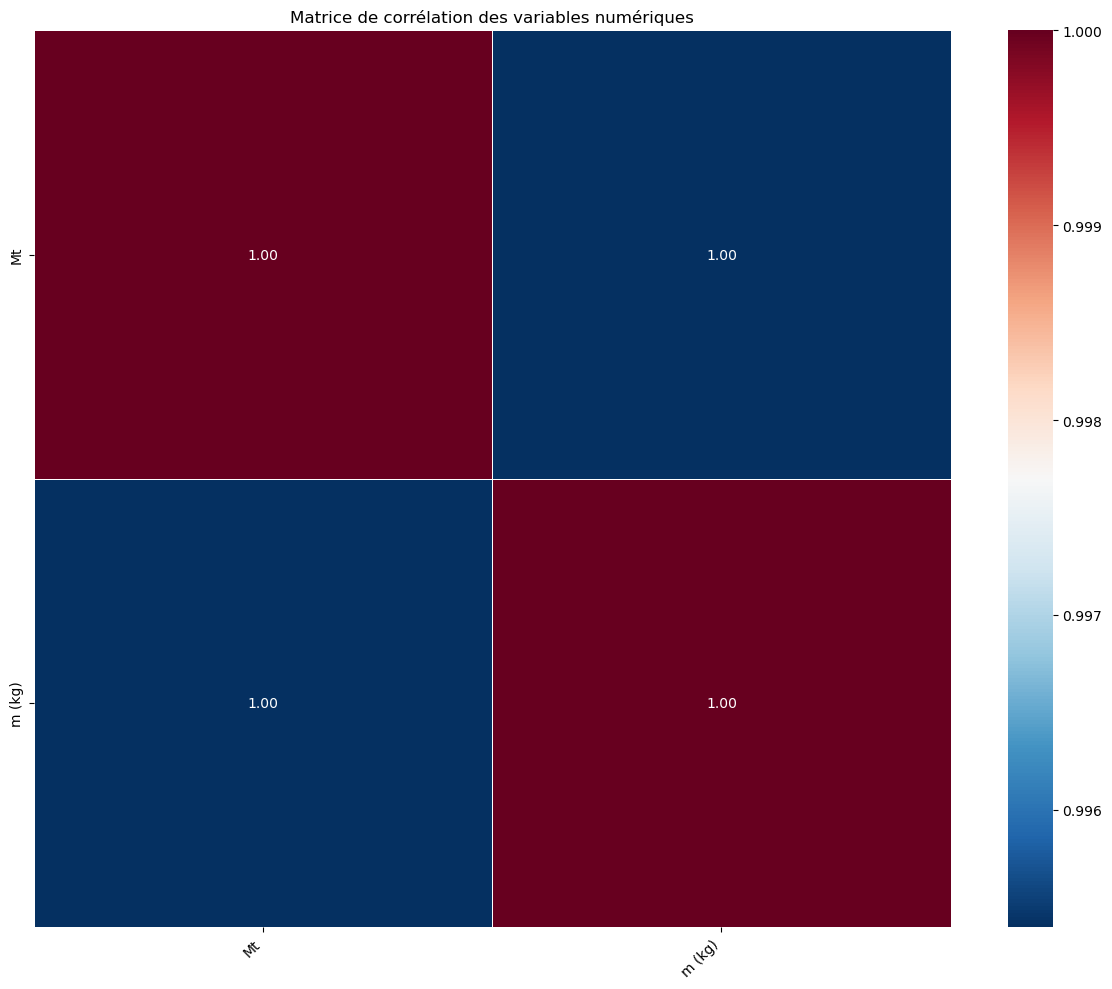

In [124]:
df_masse = df[['Mt', 'm (kg)']]
plot_correlation_matrix(df_masse)

On se rend compte qu'il y a une **forte corrélataion** entre ces 2 variables, qui pourrait entrainer une **colinéarité**. Nous prenons la décision de ne garder que la masse à vide (m (kg))

In [125]:
df = df.drop('Mt', axis=1)

# <font color='#3585CD'>Gestion des doublons</font>

## Nombre de doublons

In [126]:
df.duplicated().sum()

3503825

## Supression des doublons

In [127]:
df.drop_duplicates(inplace =True)

In [128]:
df.duplicated().sum()

0

In [129]:
df.shape

(24655, 8)

In [130]:
df = df.reset_index(drop=True)

# <font color='#3585CD'>Renommage des colonnes</font>

Pour plus de compréhension, nous allons renommer les colonnes :



*   Mk : Marque
*   Cn : Modele
*   Ewltp (g/km) : Co2
*   Ft : Carburant
*   ec (cm3) : Cylindree moteur
*   ep (KW) : Puissance moteur
*   Fuel consumption : Consommation carburant


In [131]:
renommage = {
    'Mk': 'Marque',
    'Cn': 'Modèle',
    'm (kg)' : 'Masse à vide',
    'Ewltp (g/km)': 'CO2',
    'Ft': 'Carburant',
    'ec (cm3)': 'Cylindrée moteur',
    'ep (KW)': 'Puissance moteur',
    'Fuel consumption': 'Consommation carburant'
}

# Application du renommage
df.rename(columns=renommage, inplace=True)

In [132]:
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
0,JEEP,RENEGADE,1845.0,49,petrol/electric,1332.0,96.0,2.0
1,JEEP,WRANGLER,1883.0,244,petrol,1995.0,200.0,10.8
2,JEEP,WRANGLER,1972.0,259,petrol,1995.0,200.0,11.5
3,JEEP,WRANGLER,1972.0,258,petrol,1995.0,200.0,11.5
4,JEEP,WRANGLER UNLIMITED,2348.0,79,petrol/electric,1995.0,200.0,3.5
...,...,...,...,...,...,...,...,...
24650,SKODA,SCALA,1211.0,119,petrol,999.0,70.0,5.2
24651,FORD,TRANSIT CUSTOM,2311.0,197,diesel,1995.0,95.0,7.5
24652,MERCEDES-BENZ,A 200,1440.0,144,petrol,1332.0,120.0,6.3
24653,MERCEDES-BENZ,V-KLASSE,2220.0,225,diesel,1950.0,174.0,8.6


# <font color='#3585CD'>Faut-il garder les véhicules électriques et hydrogènes ?</font>
Notre objectif est de prédire les émissions directes de CO2. Garder les véhicules électriques et hydrogènes risque de biaiser notre modèle. Nous allons donc exclure les véhicules électriques de notre dataset

In [133]:
# Vérification des émissions de CO2 des véhicules hydrogènes
df_hydrogen = df[df["Carburant"] == "hydrogen"]
df_hydrogen['CO2'].value_counts()

CO2
0    4
Name: count, dtype: int64

In [134]:
# Nous excluons les véhicules électriques et hydrogènes
df = df[(df["Carburant"] != "electric") & (df["Carburant"] != "hydrogen")]

In [135]:
df.shape

(23935, 8)

# <font color='#3585CD'>Traitement des valeurs manquantes</font>

In [136]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,Masse à vide,0.004178,1,float64
1,Consommation carburant,0.004178,1,float64


## Gestion des valeurs manquantes de la colonne Consommation carburant

In [137]:
df_fc_na = df[df['Consommation carburant'].isna()]
df_fc_na

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
23942,LAND ROVER,RANGE ROVER EVOQUE,NaN,137,diesel,1998.0,120.0,NaN


Nous allons gérer cette ligne

In [138]:
# regardons si d'autres modeles RANGE ROVER EVOQUE sont renseignés
df_jag_evoque = df[(df['Modèle'] == 'RANGE ROVER EVOQUE') & (df['Carburant'] == 'diesel') & (~df['Consommation carburant'].isna())]
df_jag_evoque.head()

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
2931,LAND ROVER,RANGE ROVER EVOQUE,1967.0,170,diesel,1998.0,120.0,6.5
2932,LAND ROVER,RANGE ROVER EVOQUE,1992.0,172,diesel,1998.0,150.0,6.6
2933,LAND ROVER,RANGE ROVER EVOQUE,1992.0,175,diesel,1998.0,150.0,6.7
2934,LAND ROVER,RANGE ROVER EVOQUE,1992.0,173,diesel,1998.0,150.0,6.6
2935,LAND ROVER,RANGE ROVER EVOQUE,1992.0,174,diesel,1998.0,150.0,6.6


In [139]:
fc_mean_jag_evoque = df_jag_evoque['Consommation carburant'].mean().round(1)
fc_mean_jag_evoque

6.5

In [140]:
df.loc[(df["Modèle"] == "RANGE ROVER EVOQUE") & (df['Consommation carburant'].isna()), "Consommation carburant"] = fc_mean_jag_evoque

In [141]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,Masse à vide,0.004178,1,float64


## Gestion des valeurs manquantes de la colonne Masse à vide

In [142]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type
0,Masse à vide,0.004178,1,float64


In [143]:
df_mkg_na = df[df['Masse à vide'].isna()]
df_mkg_na

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
23942,LAND ROVER,RANGE ROVER EVOQUE,NaN,137,diesel,1998.0,120.0,6.5


Recherchons dans le dataset si nous avons des modèles équivalents dont les variables m (kg) et Mt ne sont **pas nulles**

In [144]:
df_jag_lr = df[(df['Modèle'] == 'RANGE ROVER EVOQUE') & (df['Carburant'] == 'diesel') & (df['Puissance moteur'] == 120) & (~df['Masse à vide'].isna())]
df_jag_lr

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
2931,LAND ROVER,RANGE ROVER EVOQUE,1967.0,170,diesel,1998.0,120.0,6.5
2936,LAND ROVER,RANGE ROVER EVOQUE,1967.0,173,diesel,1998.0,120.0,6.6
2937,LAND ROVER,RANGE ROVER EVOQUE,1967.0,171,diesel,1998.0,120.0,6.5
2940,LAND ROVER,RANGE ROVER EVOQUE,1967.0,174,diesel,1998.0,120.0,6.6
2941,LAND ROVER,RANGE ROVER EVOQUE,1967.0,172,diesel,1998.0,120.0,6.6
2943,LAND ROVER,RANGE ROVER EVOQUE,1967.0,172,diesel,1998.0,120.0,6.5
2969,LAND ROVER,RANGE ROVER EVOQUE,1855.0,164,diesel,1998.0,120.0,6.3
2970,LAND ROVER,RANGE ROVER EVOQUE,1855.0,160,diesel,1998.0,120.0,6.1
2971,LAND ROVER,RANGE ROVER EVOQUE,1855.0,165,diesel,1998.0,120.0,6.3
2972,LAND ROVER,RANGE ROVER EVOQUE,1855.0,162,diesel,1998.0,120.0,6.2


In [145]:
fc_mean_masse_jag_evoque = df_jag_evoque['Masse à vide'].mean().round(1)
fc_mean_masse_jag_evoque

1955.3

In [146]:
# pour les mêmes modèles, la variable Masse à vide est égale à 1967
df['Masse à vide'] = df['Masse à vide'].fillna(fc_mean_masse_jag_evoque)

In [147]:
# Vérification
df.loc[23942].to_frame().T

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
23942,LAND ROVER,RANGE ROVER EVOQUE,1955.3,137,diesel,1998.0,120.0,6.5


In [148]:
data_na = display_missing_values(df)
data_na

,Colonne,Valeurs manquantes (%),Nombre de valeurs manquantes,Type


In [149]:
# ré inisialisation des indexes
df = df.reset_index(drop=True)
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant
0,JEEP,RENEGADE,1845.0,49,petrol/electric,1332.0,96.0,2.0
1,JEEP,WRANGLER,1883.0,244,petrol,1995.0,200.0,10.8
2,JEEP,WRANGLER,1972.0,259,petrol,1995.0,200.0,11.5
3,JEEP,WRANGLER,1972.0,258,petrol,1995.0,200.0,11.5
4,JEEP,WRANGLER UNLIMITED,2348.0,79,petrol/electric,1995.0,200.0,3.5
...,...,...,...,...,...,...,...,...
23930,SKODA,SCALA,1211.0,119,petrol,999.0,70.0,5.2
23931,FORD,TRANSIT CUSTOM,2311.0,197,diesel,1995.0,95.0,7.5
23932,MERCEDES-BENZ,A 200,1440.0,144,petrol,1332.0,120.0,6.3
23933,MERCEDES-BENZ,V-KLASSE,2220.0,225,diesel,1950.0,174.0,8.6


# <font color='#3585CD'>Distribution des variables catégorielles</font>

## Analyse par marque

### Valeurs uniques

In [150]:
sorted(df['Marque'].unique())

['ALFA ROMEO',
 'ALPINA',
 'ALPINE',
 'ASTON MARTIN',
 'AUDI',
 'BENTLEY',
 'BMW',
 'BUGATTI',
 'CADILLAC',
 'CASELANI',
 'CATERHAM',
 'CHEVROLET',
 'CITROEN',
 'CUPRA',
 'DACIA',
 'DALLARA',
 'DONKERVOORT',
 'DR',
 'DS',
 'FERRARI',
 'FIAT',
 'FORD',
 'FORD-CNG-TECHNIK',
 'HONDA',
 'HYUNDAI',
 'INEOS',
 'JAGUAR',
 'JEEP',
 'KIA',
 'KTM',
 'LAMBORGHINI',
 'LAND ROVER',
 'LEXUS',
 'LOTUS',
 'LYNK&CO',
 'MASERATI',
 'MAZDA',
 'MC LAREN',
 'MCLAREN',
 'MERCEDES AMG',
 'MERCEDES BENZ',
 'MERCEDES-BENZ',
 'MG',
 'MINI',
 'MITSUBISHI',
 'MITSUBISHI MOTORS (THAILAND)',
 'MITSUBISHI MOTORS CORPORATION',
 'MITSUBISHI MOTORS THAILAND',
 'MORGAN',
 'NISSAN',
 'OPEL',
 'PEUGEOT',
 'PORSCHE',
 'RENAULT',
 'ROLLS ROYCE',
 'ROLLS-ROYCE',
 'SEAT',
 'SECMA',
 'SKODA',
 'SSANGYONG',
 'SUBARU',
 'SUZUKI',
 'TOYOTA',
 'VOLKSWAGEN',
 'VOLVO']

### Remplacement

Certaines valeurs peuvent être regroupées, comme par exemple :

*   'MC LAREN', 'MCLAREN'
*   'MERCEDES AMG', 'MERCEDES BENZ', 'MERCEDES-BENZ'
*   'MITSUBISHI', 'MITSUBISHI MOTORS CORPORATION', 'MITSUBISHI MOTORS THAILAND'


In [151]:
replace_mk = {'MC LAREN' : 'MCLAREN',
              'MERCEDES AMG' : 'MERCEDES BENZ',
              'MERCEDES-BENZ' : 'MERCEDES BENZ',
              'MITSUBISHI MOTORS CORPORATION' : 'MITSUBISHI',
              'MITSUBISHI MOTORS THAILAND' : 'MITSUBISHI',
              'MITSUBISHI MOTORS (THAILAND)' : 'MITSUBISHI',
              'FORD-CNG-TECHNIK' : 'FORD',
              'ROLLS ROYCE' : 'ROLLS-ROYCE'}
df['Marque'] = df['Marque'].replace(replace_mk)

In [152]:
df['Marque'].nunique()

57

### Analyse

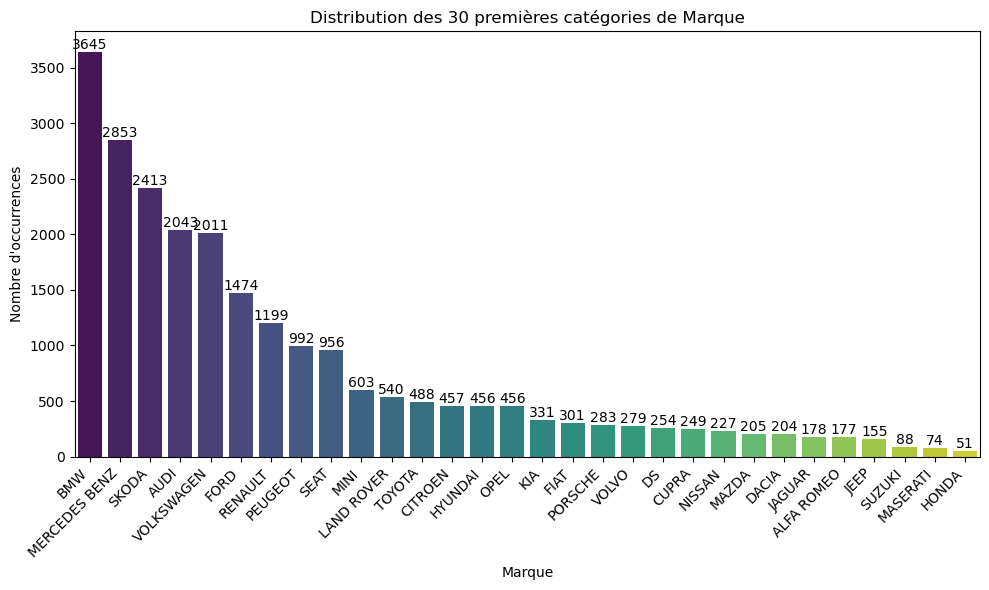

In [207]:
analyser_variable_categorielle(df, 'Marque', 30, False)

## Analyse par carburant

### Valeurs uniques

In [154]:
sorted(df['Carburant'].unique())

['diesel', 'diesel/electric', 'e85', 'lpg', 'ng', 'petrol', 'petrol/electric']

### Remplacement

Certaines valeurs peuvent être regroupées :



*   'diesel/electric' & 'petrol/electric' sont des véhicules hybride
*   'lpg' & 'ng' sont des énergies au gaz
*   'petrol' sera renommé en 'essence' pour plus de compréhension.


In [155]:
replace_ft = {
              'petrol' : 'essence',
              'diesel/electric' : 'hybride',
              'petrol/electric' : 'hybride',
              'lpg' : 'gaz',
              'ng' : 'gaz'}
df['Carburant'] = df['Carburant'].replace(replace_ft)

### Analyse

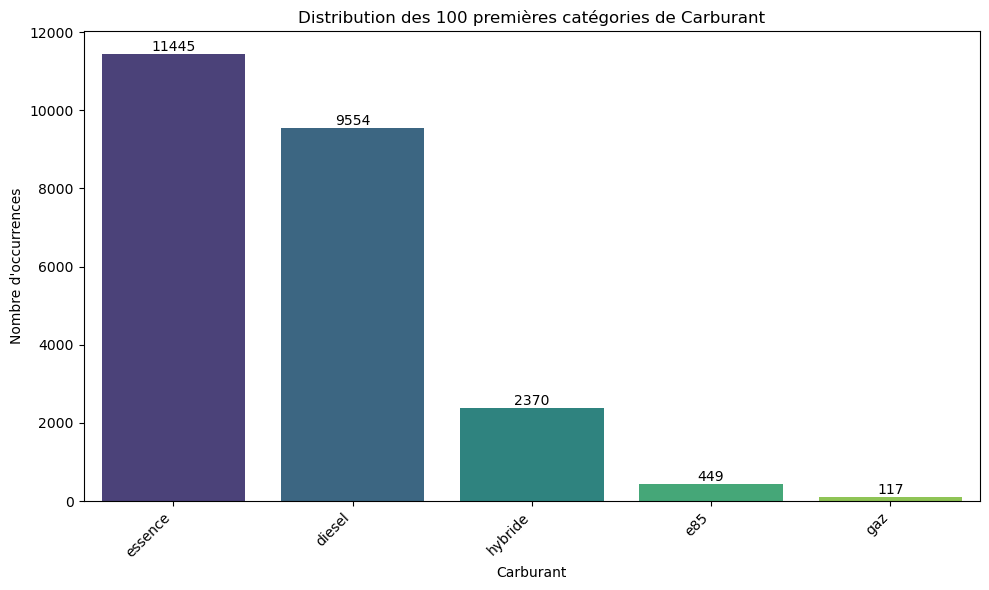

In [156]:
analyser_variable_categorielle(df=df, variable='Carburant', display_array=False)

## Analyse par modèle de voiture

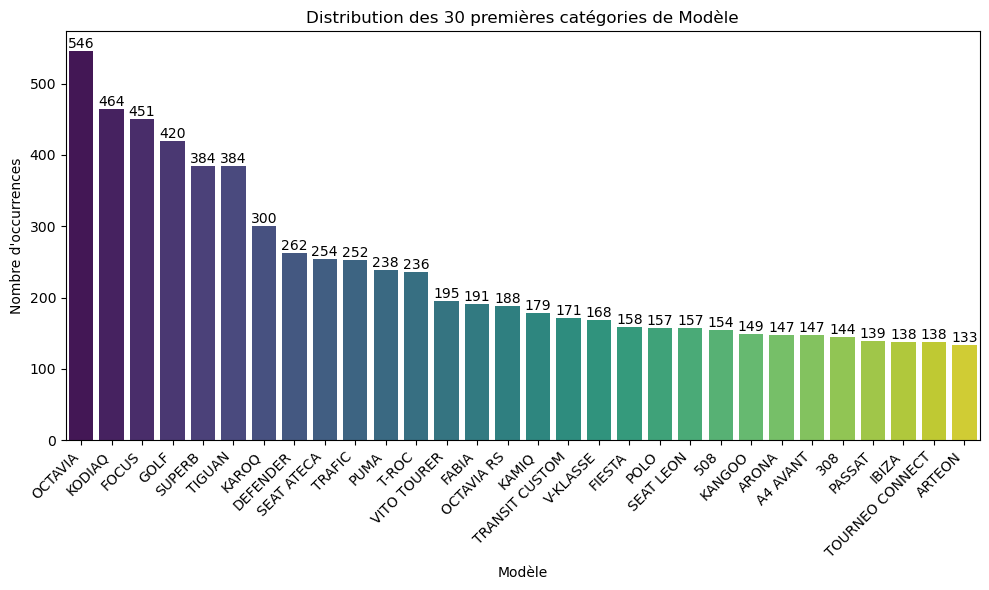

In [157]:
analyser_variable_categorielle(df, 'Modèle', 30, display_array=False)

# <font color='#3585CD'>Distribution des variables numériques</font>

## Sélection des colonnes numériques

In [158]:
# Sélection des colonnes numériques
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_vars

['Masse à vide',
 'CO2',
 'Cylindrée moteur',
 'Puissance moteur',
 'Consommation carburant']

## Analyse de la masse du véhicule Masse à vide

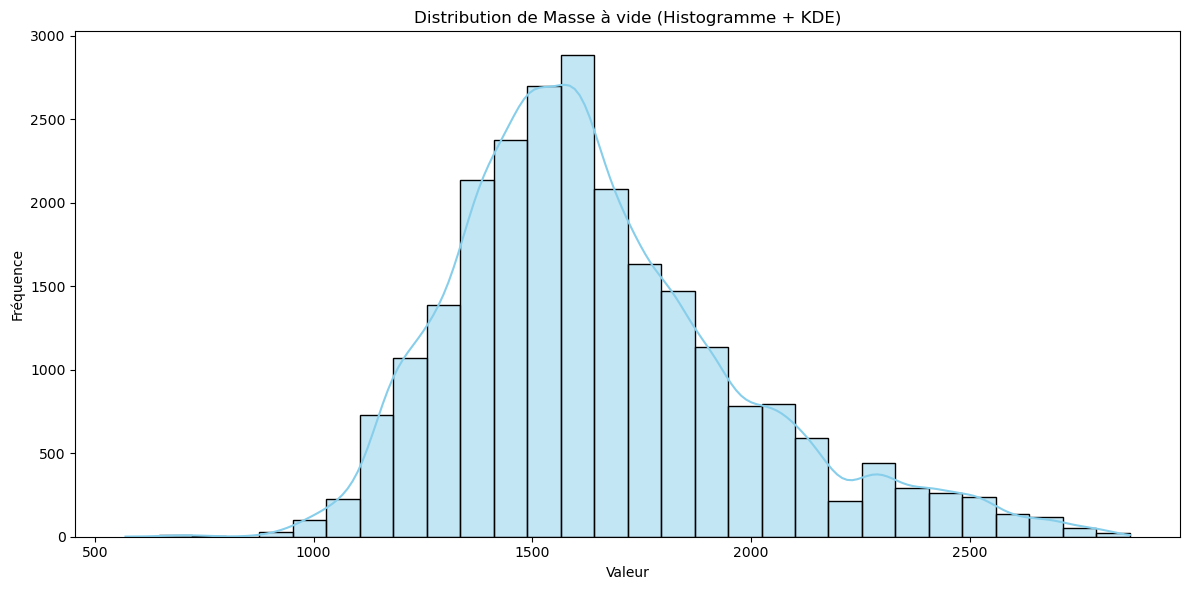

In [159]:
analyser_variables_numeriques(df, ['Masse à vide'])

## Analyse des émissions spécifiques de CO2

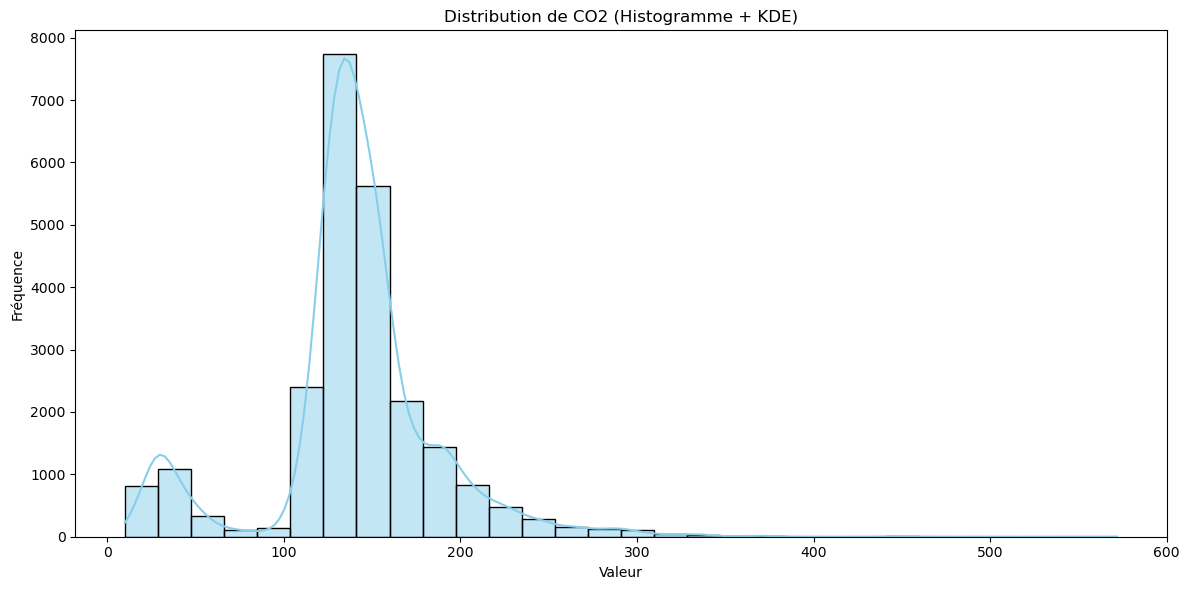

In [160]:
analyser_variables_numeriques(df, ['CO2'], 30)

## Analyse de la cylindrée moteur

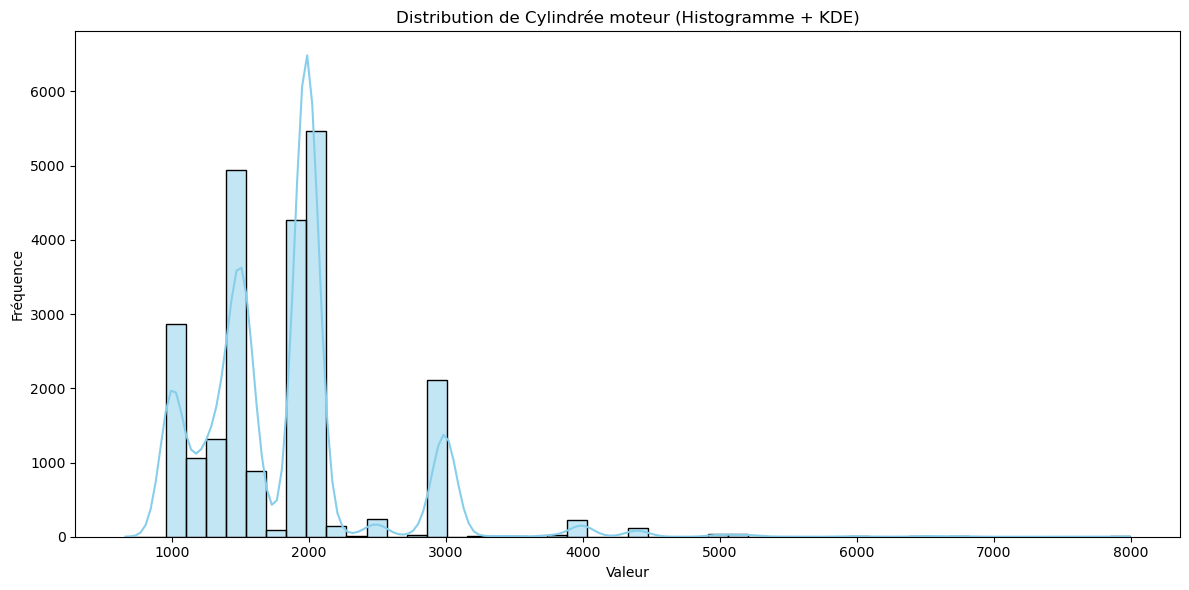

In [161]:
analyser_variables_numeriques(df, ['Cylindrée moteur'], 50)

## Analyse de la puissance du moteur

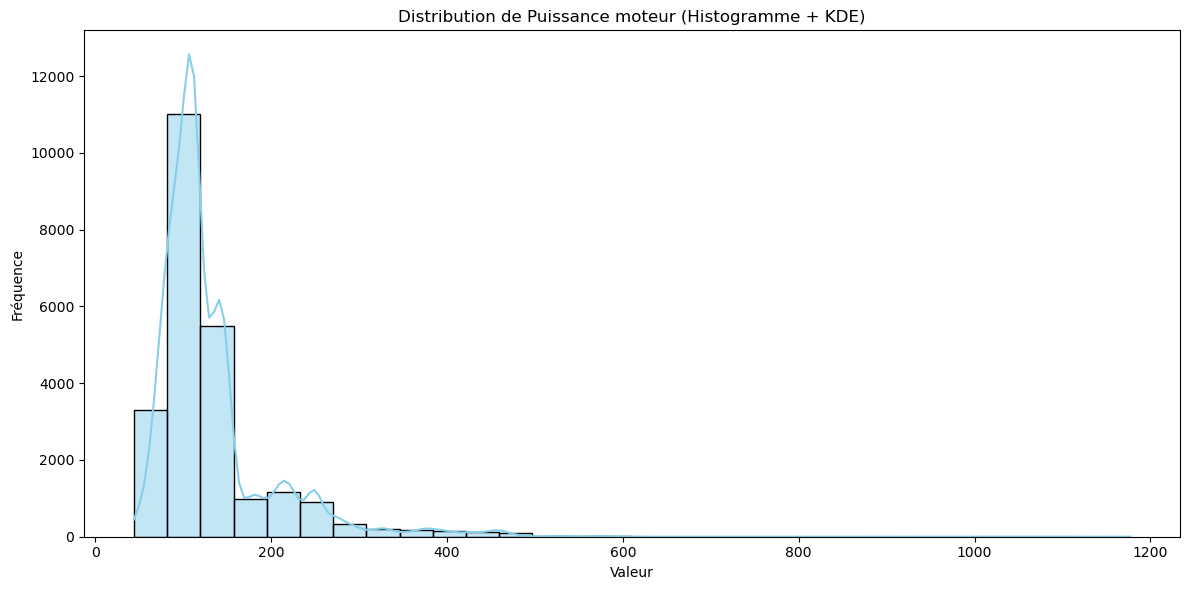

In [162]:
analyser_variables_numeriques(df, ['Puissance moteur'])

## Analyse de la Consommation carburant

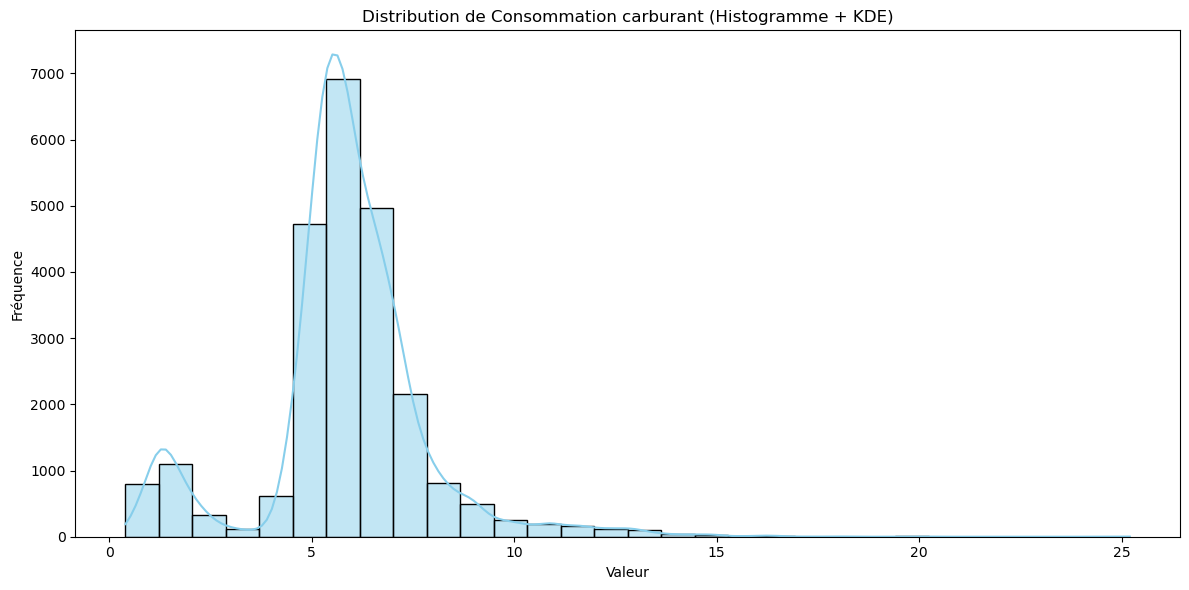

In [163]:
analyser_variables_numeriques(df, ['Consommation carburant'])

# <font color='#3585CD'>Création d'indicateurs</font>

## Indicateur de Charge Spécifique du Moteur (ICSM)

`ICSM = Puissance (kW) / Masse du véhicule (kg)`

**Interprétation** :

*   Faible ICSM → Voiture puissante et légère (moins d’effort, moins de CO₂).
*   Élevé ICSM → Voiture sous-motorisée (forte sollicitation, plus de CO₂).

In [164]:
df['ICSM'] = df['Puissance moteur'] / df['Masse à vide']

## Indicateur de Consommation Énergétique (ICE)

`ICE = Puissance (kW) / Cylindrée (cm³)`

**Interprétation** :

*   Faible ICE → Moteur optimisé (ex. turbo downsizing).
*   Élevé ICE → Moteur gourmand et peu efficient.

In [165]:
df['ICE'] = df['Puissance moteur'] / df['Cylindrée moteur']

## Indicateur de Densité Energétique du Carburant (IDEC)

`IDEC = Cylindrée (cm³) / Masse du véhicule (kg)`

**Interprétation** :

*   Faible IDEC → Moteur bien dimensionné (moins d’effort, moins de CO₂).
*   Élevé IDEC → Moteur sous-dimensionné (forte sollicitation, plus de CO₂).

In [166]:
df['IDEC'] = df['Cylindrée moteur'] / df['Masse à vide']

## Indicateur de Consommation Spécifique (ICS)

`ICS = Puissance produite (kWh) / Consommation de carburant (g)`

**Interprétation** :

*   Faible ICS : Moteur efficace, consomme moins de carburant et génère moins de CO₂ pour produire la même puissance.
*   Élevé ICS : Moteur inefficace, consomme plus de carburant et génère plus de CO₂ pour produire la même puissance.

In [167]:
df['ICS'] = df['Puissance moteur'] / df['Consommation carburant']

In [168]:
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0,0.052033,0.072072,0.721951,48.000000
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8,0.106213,0.100251,1.059480,18.518519
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5,0.101420,0.100251,1.011663,17.391304
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5,0.101420,0.100251,1.011663,17.391304
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5,0.085179,0.100251,0.849659,57.142857
...,...,...,...,...,...,...,...,...,...,...,...,...
23930,SKODA,SCALA,1211.0,119,essence,999.0,70.0,5.2,0.057803,0.070070,0.824938,13.461538
23931,FORD,TRANSIT CUSTOM,2311.0,197,diesel,1995.0,95.0,7.5,0.041108,0.047619,0.863263,12.666667
23932,MERCEDES BENZ,A 200,1440.0,144,essence,1332.0,120.0,6.3,0.083333,0.090090,0.925000,19.047619
23933,MERCEDES BENZ,V-KLASSE,2220.0,225,diesel,1950.0,174.0,8.6,0.078378,0.089231,0.878378,20.232558


# <font color='#3585CD'>Analyse du CO2 en fonction de certaines variables</font>

### Analyse du CO2 en fonction de la masse du véhicule

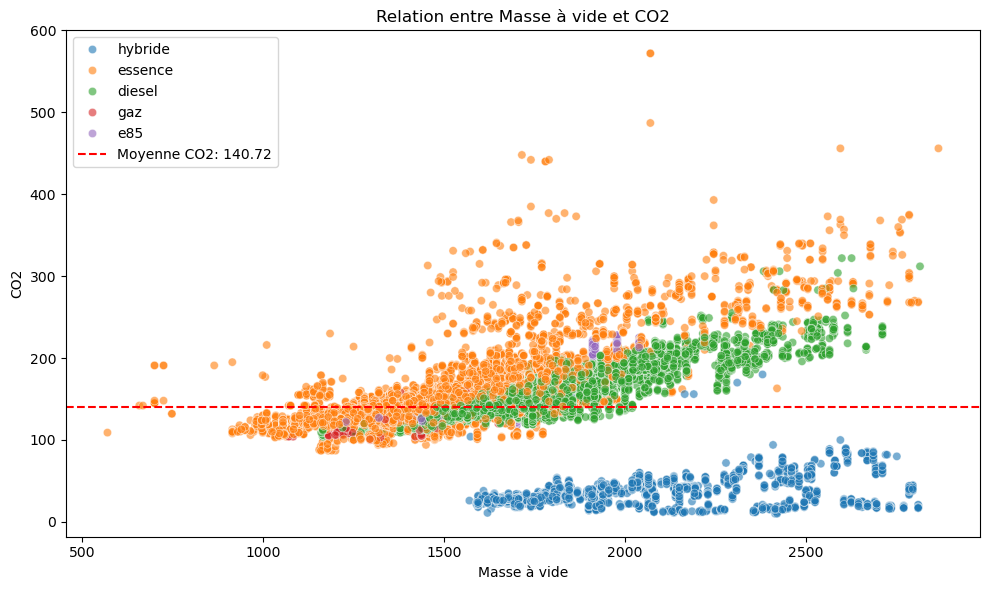

In [169]:
plot_scatter_co2(df, "Masse à vide")

On observe que les véhicules plus lourds tendent à émettre plus de CO₂, avec une distinction entre les types de carburant.

### Analyse du CO2 en fonction de la puissance du moteur.

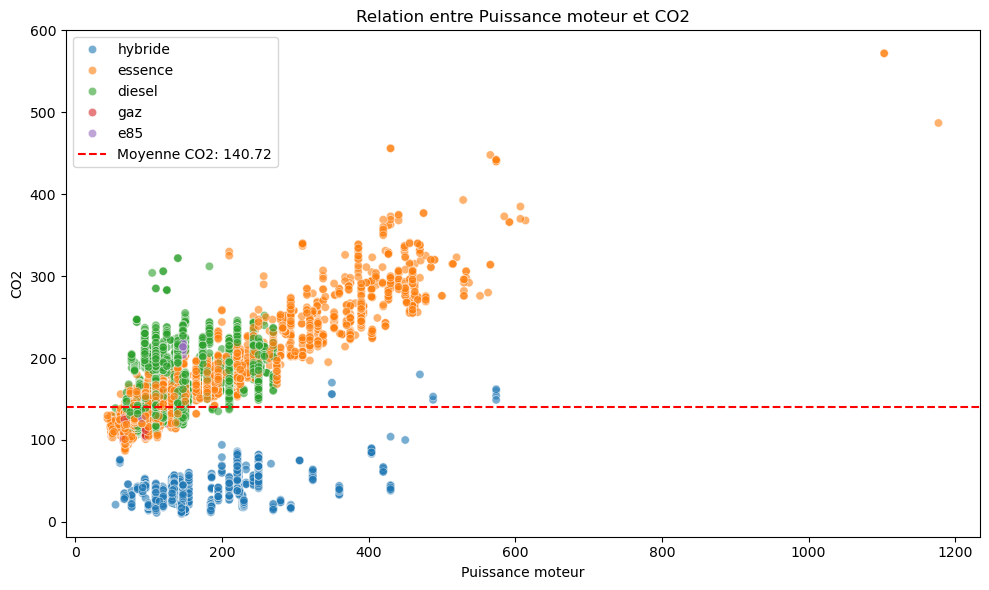

In [170]:
plot_scatter_co2(df, "Puissance moteur")

### Analyse du CO2 en fonction du carburant



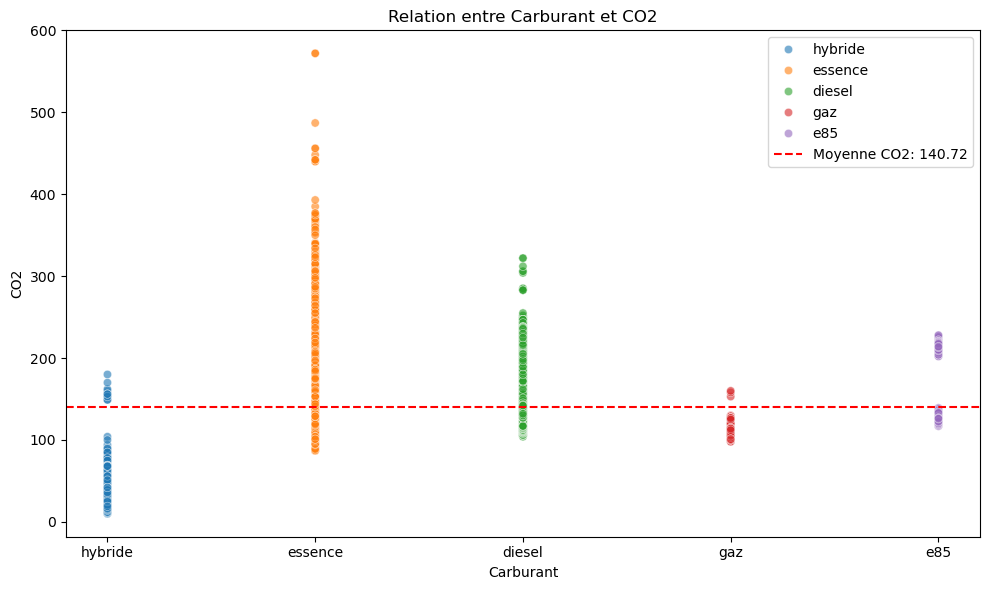

In [171]:
plot_scatter_co2(df, "Carburant")

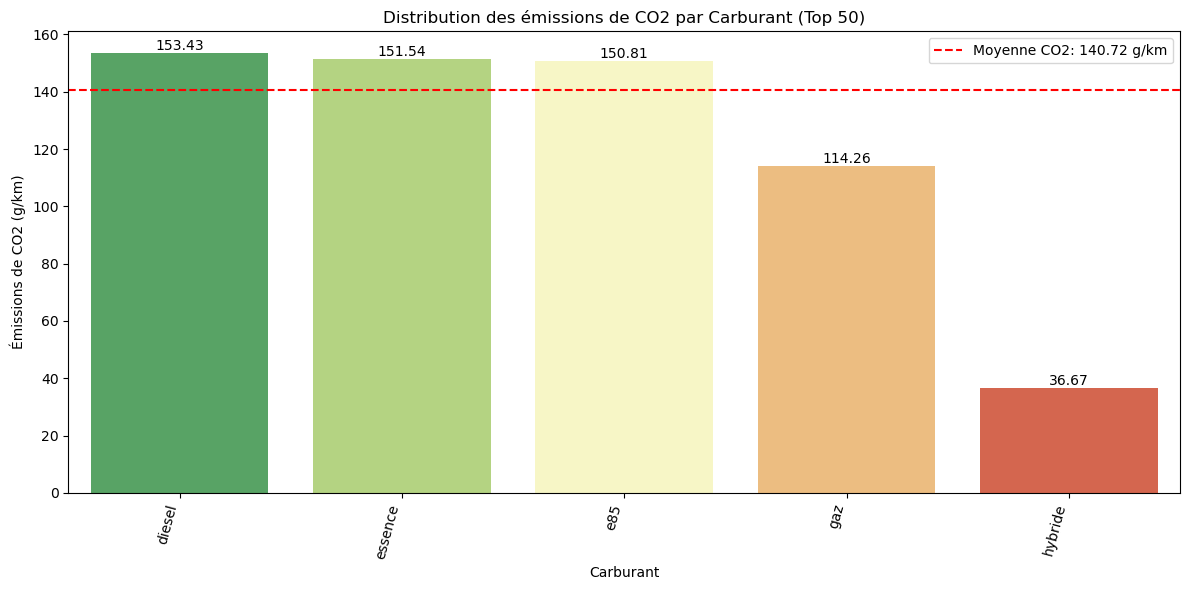

In [172]:
analyser_hist_co2_par_variable(df, 'Carburant')

### Analyse du CO2 en fonction de la marque

**Top des marques les plus polluantes**

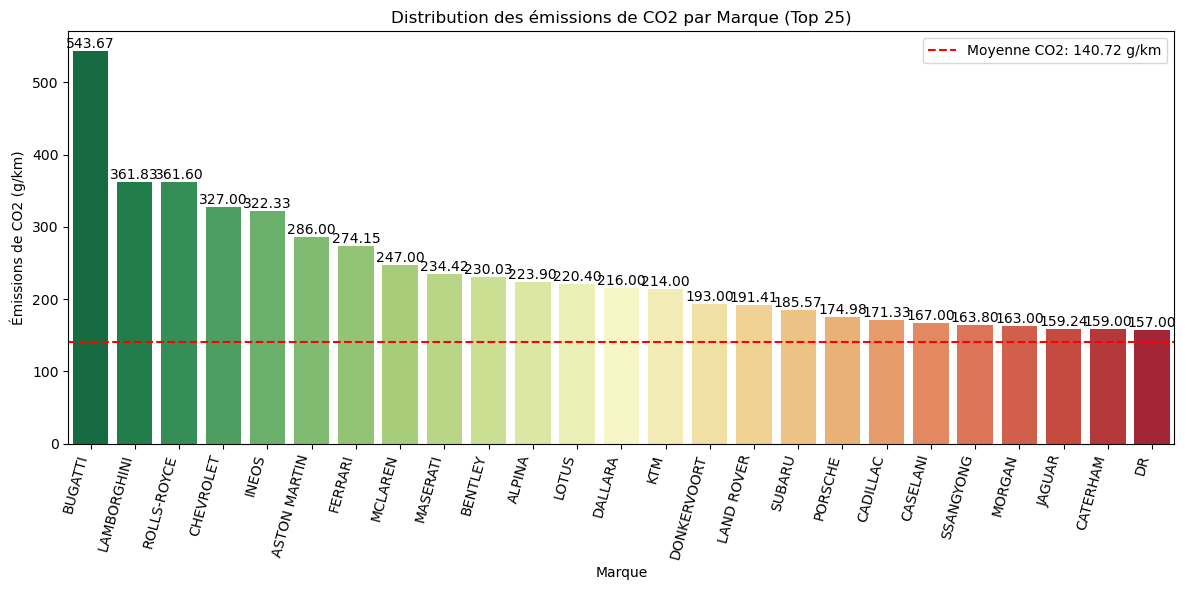

In [209]:
analyser_hist_co2_par_variable(df, 'Marque', 25)

### Analyse du CO2 en fonction du modèle de voiture

**Top des modèles les plus polluants**

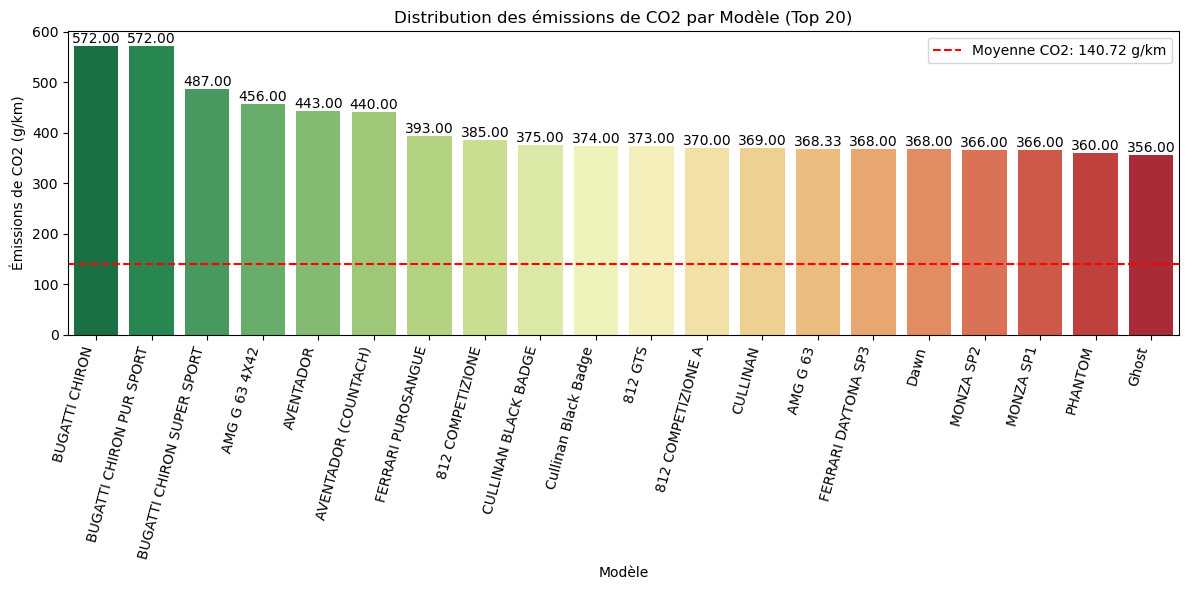

In [210]:
analyser_hist_co2_par_variable(df, 'Modèle', 20)

**Top des modèles les moins polluants**

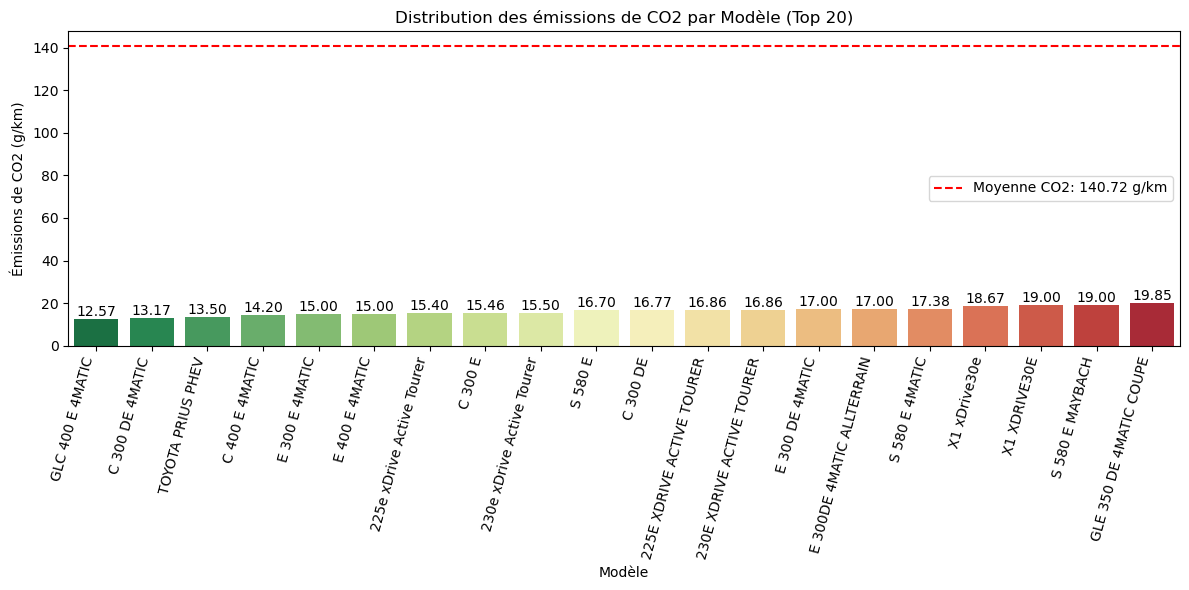

In [211]:
analyser_hist_co2_par_variable(df, 'Modèle', 20, order='asc')

### Analyse du CO2 en fonction de la consommation

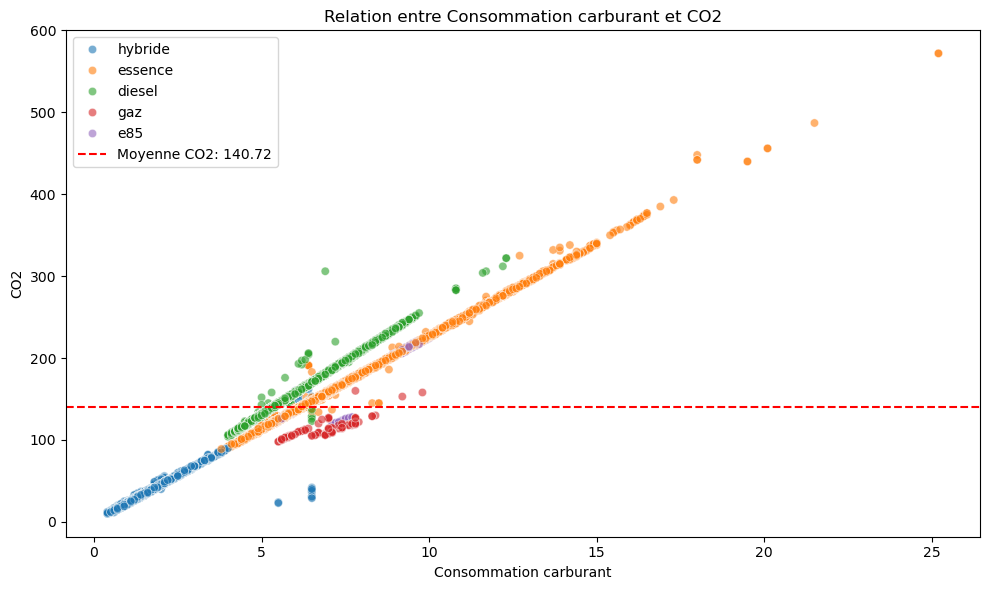

In [176]:
plot_scatter_co2(df, "Consommation carburant")

### Analyse du CO2 en fonction des indicateurs ICSM, ICE, IDEC, ICS

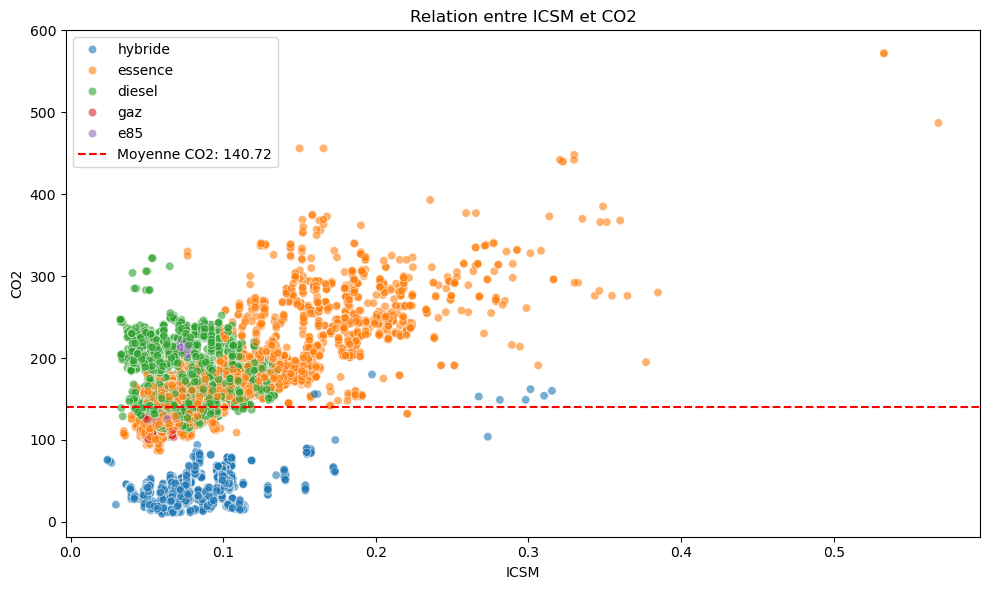

In [177]:
plot_scatter_co2(df, "ICSM")

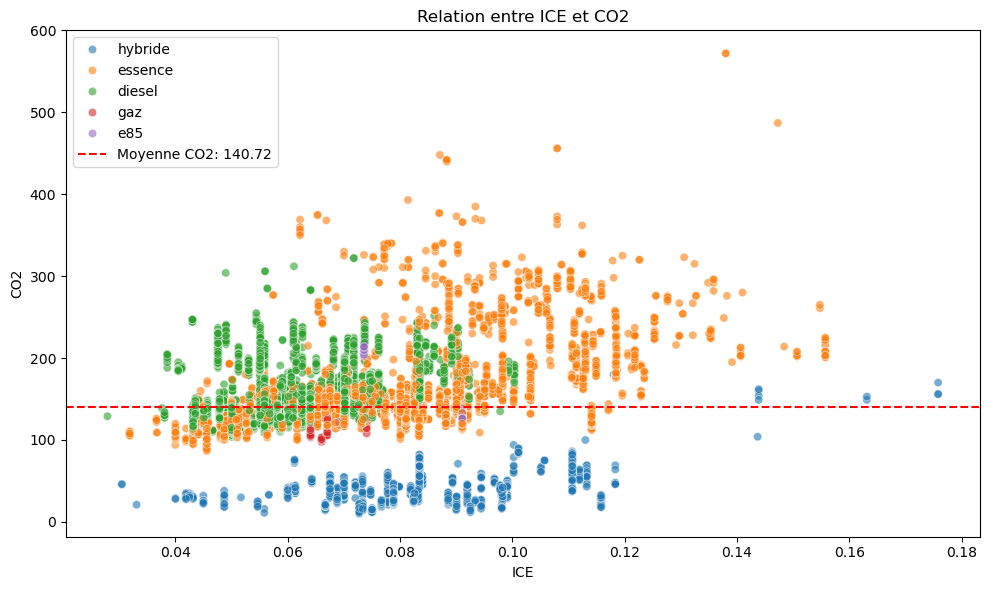

In [178]:
plot_scatter_co2(df, "ICE")

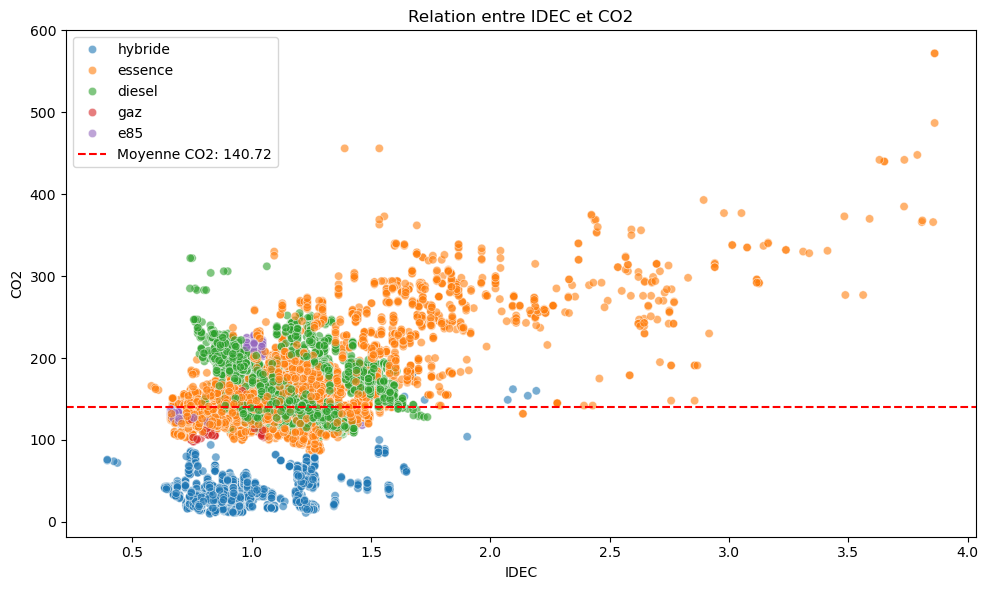

In [179]:
plot_scatter_co2(df, "IDEC")

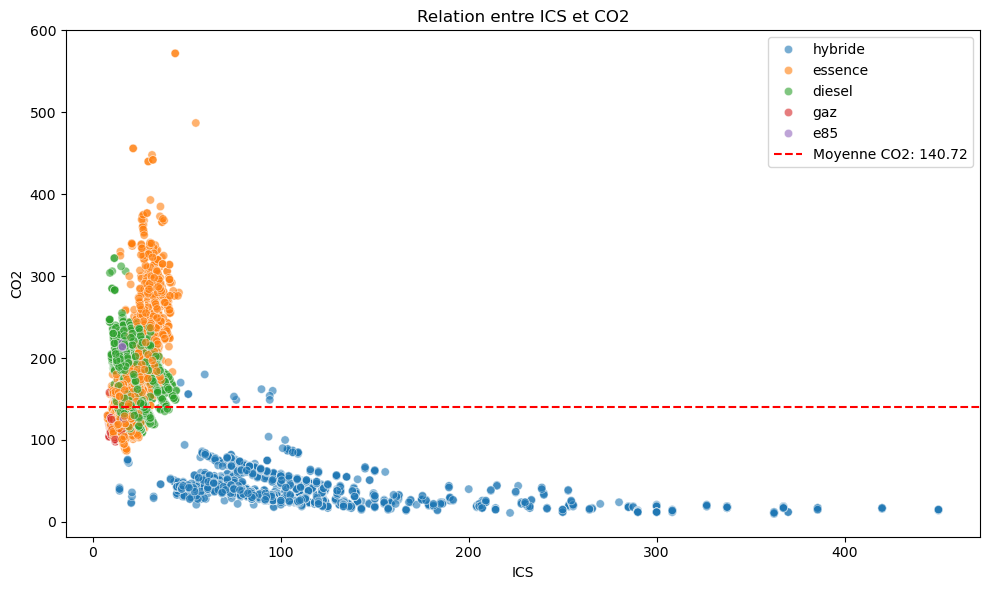

In [180]:
plot_scatter_co2(df, "ICS")

# <font color='#3585CD'>Corrélation des variables numériques</font>

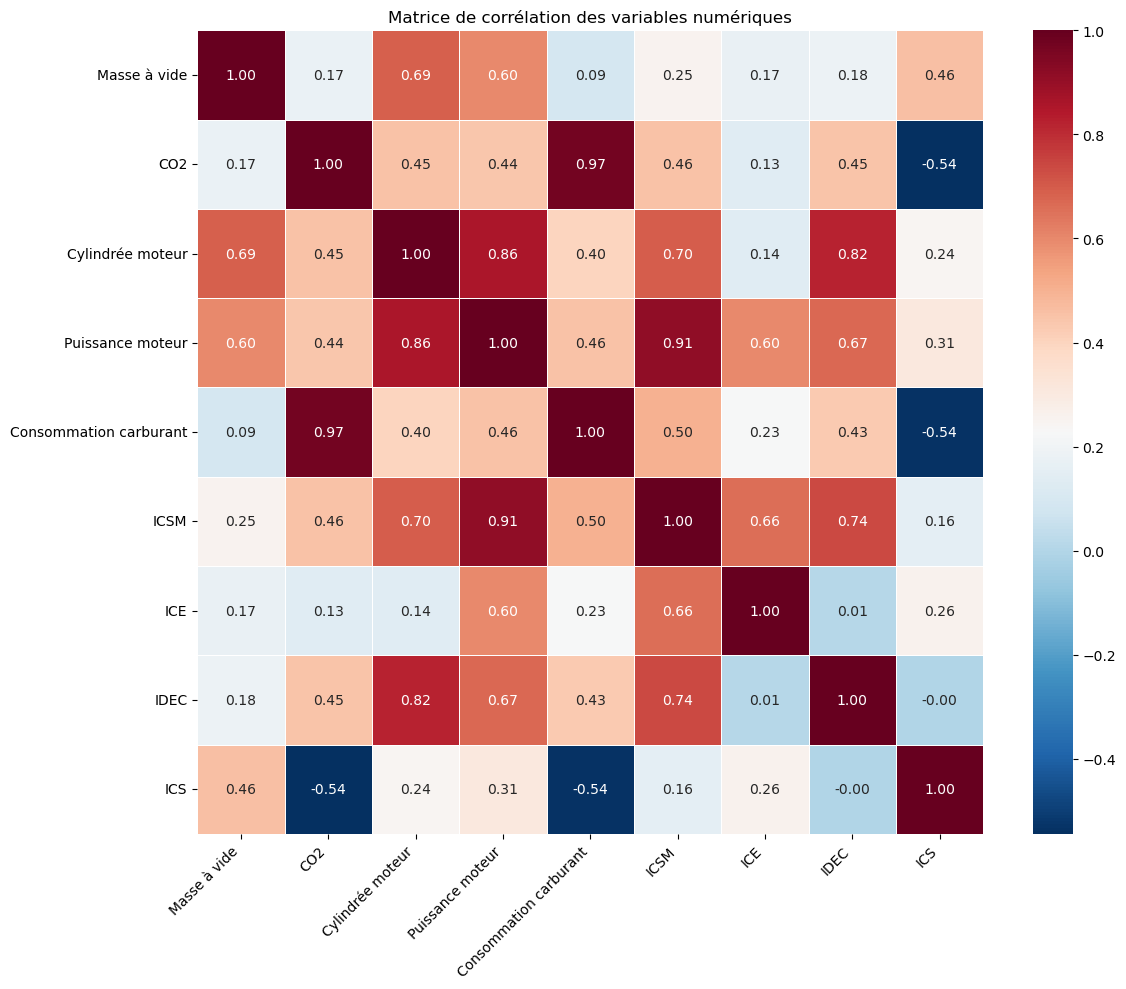

In [181]:
plot_correlation_matrix(df)

In [182]:
num_numeric_cols = df.select_dtypes(include=['number']).columns
num_numeric_cols

for col in num_numeric_cols:
  calculer_correlation(df, col, 'CO2')

Corrélation entre Masse à vide et CO2 : 0.17
Corrélation faible.

Corrélation entre CO2 et CO2 : 1.00
Très forte corrélation.

Corrélation entre Cylindrée moteur et CO2 : 0.45
Corrélation modérée.

Corrélation entre Puissance moteur et CO2 : 0.44
Corrélation modérée.

Corrélation entre Consommation carburant et CO2 : 0.97
Très forte corrélation.

Corrélation entre ICSM et CO2 : 0.46
Corrélation modérée.

Corrélation entre ICE et CO2 : 0.13
Pas de corrélation linéaire significative.

Corrélation entre IDEC et CO2 : 0.45
Corrélation modérée.

Corrélation entre ICS et CO2 : -0.54
Corrélation modérée.



# <font color='#3585CD'>Analyse des outliers</font>

## Masse à vide

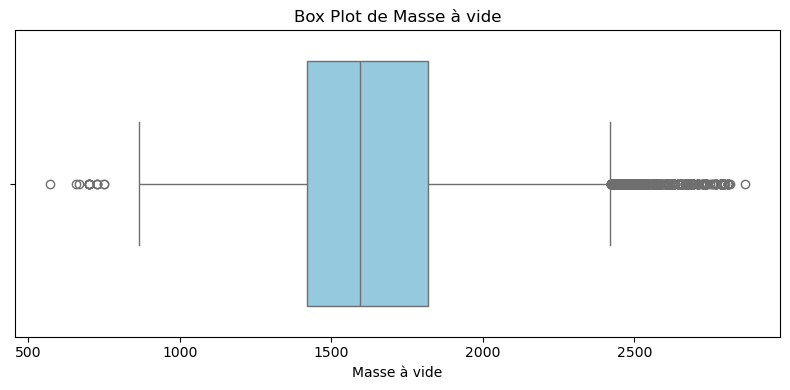

,Nb_Outliers,Pourcentage
Masse à vide,800,3.34


In [183]:
detecter_outliers(df['Masse à vide'])

In [184]:
df_outliers_masse = df[df['Masse à vide'] < 750].sort_values(by='Masse à vide', ascending=True)
df_outliers_masse.head(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
2976,CATERHAM,SEVEN S3,570.0,109,essence,658.0,62.0,4.8,0.108772,0.094225,1.154386,12.916667
5150,SECMA,FUN 1600,658.0,142,essence,1598.0,77.0,6.3,0.117021,0.048185,2.428571,12.222222
5151,SECMA,FUN 1600 BUGGY,668.0,142,essence,1598.0,77.0,6.3,0.115269,0.048185,2.392216,12.222222
2977,CATERHAM,SEVEN S3,700.0,191,essence,1999.0,176.0,6.4,0.251429,0.088044,2.855714,27.500000
2978,CATERHAM,SEVEN S3,700.0,145,essence,1596.0,100.0,6.4,0.142857,0.062657,2.280000,15.625000
2979,CATERHAM,SEVEN S3,700.0,145,essence,1596.0,100.0,8.5,0.142857,0.062657,2.280000,11.764706
2980,CATERHAM,SEVEN S3,700.0,145,essence,1596.0,100.0,8.3,0.142857,0.062657,2.280000,12.048193
2981,CATERHAM,SEVEN SV,700.0,191,essence,1999.0,176.0,6.4,0.251429,0.088044,2.855714,27.500000
2983,CATERHAM,SEVEN SV,700.0,145,essence,1596.0,100.0,8.5,0.142857,0.062657,2.280000,11.764706
15692,CATERHAM,SEVEN S3,700.0,148,essence,1999.0,127.0,6.7,0.181429,0.063532,2.855714,18.955224


In [185]:
df_outliers_masse = df[df['Masse à vide'] > 2500].sort_values(by='Masse à vide', ascending=True)
df_outliers_masse.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
17346,BMW,XM LABEL,2795.0,45,hybride,4395.0,430.0,2.0,0.153846,0.097838,1.572451,215.000000
22757,BMW,XM LABEL,2795.0,39,hybride,4395.0,430.0,1.7,0.153846,0.097838,1.572451,252.941176
23315,BMW,XM LABEL,2795.0,42,hybride,4395.0,430.0,1.8,0.153846,0.097838,1.572451,238.888889
20019,BMW,XM LABEL,2795.0,38,hybride,4395.0,430.0,1.7,0.153846,0.097838,1.572451,252.941176
22100,BMW,XM LABEL,2795.0,44,hybride,4395.0,430.0,2.0,0.153846,0.097838,1.572451,215.000000
20512,LAND ROVER,RANGE ROVER,2800.0,270,essence,4395.0,452.0,11.9,0.161429,0.102844,1.569643,37.983193
2788,LAND ROVER,RANGE ROVER,2810.0,20,hybride,2996.0,294.0,0.9,0.104626,0.098131,1.066192,326.666667
2593,LAND ROVER,RANGE ROVER SPORT,2810.0,19,hybride,2996.0,294.0,0.9,0.104626,0.098131,1.066192,326.666667
2592,LAND ROVER,RANGE ROVER SPORT,2810.0,20,hybride,2996.0,294.0,0.9,0.104626,0.098131,1.066192,326.666667
15345,LAND ROVER,RANGE ROVER SPORT,2810.0,18,hybride,2996.0,294.0,0.8,0.104626,0.098131,1.066192,367.500000


## Cylindrée moteur

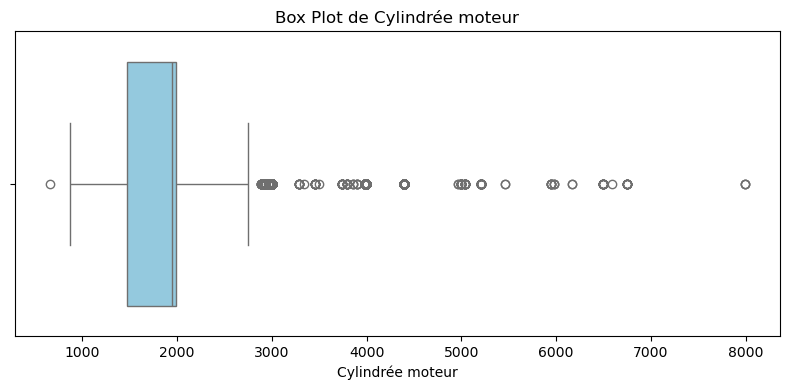

,Nb_Outliers,Pourcentage
Cylindrée moteur,2616,10.93


In [186]:
detecter_outliers(df['Cylindrée moteur'])

In [187]:
df_outliers_CO2 = df[df['Cylindrée moteur'] > 4000].sort_values(by='Cylindrée moteur', ascending=True)
df_outliers_CO2.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
14501,FERRARI,812 COMPETIZIONE,1740.0,385,essence,6496.0,607.0,16.9,0.348851,0.093442,3.733333,35.917160
14507,FERRARI,MONZA SP2,1706.0,366,essence,6496.0,592.0,16.1,0.347011,0.091133,3.807737,36.770186
14522,LAMBORGHINI,AVENTADOR,1740.0,442,essence,6498.0,574.0,18.0,0.329885,0.088335,3.734483,31.888889
14527,LAMBORGHINI,AVENTADOR,1790.0,442,essence,6498.0,574.0,18.0,0.320670,0.088335,3.630168,31.888889
14521,LAMBORGHINI,AVENTADOR,1715.0,448,essence,6498.0,566.0,18.0,0.330029,0.087104,3.788921,31.444444
14517,LAMBORGHINI,AVENTADOR,1780.0,440,essence,6498.0,574.0,19.5,0.322472,0.088335,3.650562,29.435897
14516,LAMBORGHINI,AVENTADOR (COUNTACH),1780.0,440,essence,6498.0,574.0,19.5,0.322472,0.088335,3.650562,29.435897
2947,ROLLS-ROYCE,Dawn,2705.0,368,essence,6592.0,441.0,16.2,0.163031,0.066899,2.436969,27.222222
22118,ROLLS-ROYCE,GHOST EWB,2605.0,357,essence,6749.0,420.0,15.7,0.161228,0.062231,2.590787,26.751592
2943,ROLLS-ROYCE,Ghost,2565.0,356,essence,6749.0,420.0,15.6,0.163743,0.062231,2.631189,26.923077


## CO2

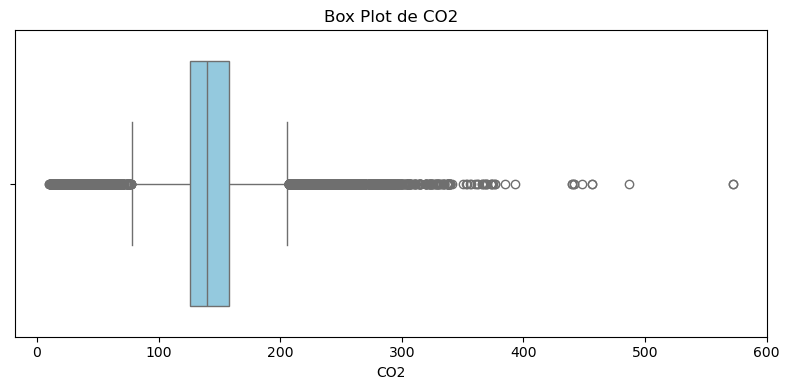

,Nb_Outliers,Pourcentage
CO2,3895,16.27


In [188]:
detecter_outliers(df['CO2'])

In [189]:
df_outliers_CO2 = df[df['CO2'] > 400].sort_values(by='CO2', ascending=True)
df_outliers_CO2.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
14516,LAMBORGHINI,AVENTADOR (COUNTACH),1780.0,440,essence,6498.0,574.0,19.5,0.322472,0.088335,3.650562,29.435897
14517,LAMBORGHINI,AVENTADOR,1780.0,440,essence,6498.0,574.0,19.5,0.322472,0.088335,3.650562,29.435897
14522,LAMBORGHINI,AVENTADOR,1740.0,442,essence,6498.0,574.0,18.0,0.329885,0.088335,3.734483,31.888889
14527,LAMBORGHINI,AVENTADOR,1790.0,442,essence,6498.0,574.0,18.0,0.320670,0.088335,3.630168,31.888889
14521,LAMBORGHINI,AVENTADOR,1715.0,448,essence,6498.0,566.0,18.0,0.330029,0.087104,3.788921,31.444444
11578,MERCEDES BENZ,AMG G 63 4X42,2866.0,456,essence,3982.0,430.0,20.1,0.150035,0.107986,1.389393,21.393035
19997,MERCEDES BENZ,AMG G 63 4X42,2595.0,456,essence,3982.0,430.0,20.1,0.165703,0.107986,1.534489,21.393035
20717,BUGATTI,BUGATTI CHIRON SUPER SPORT,2070.0,487,essence,7993.0,1177.0,21.5,0.568599,0.147254,3.861353,54.744186
5128,BUGATTI,BUGATTI CHIRON PUR SPORT,2070.0,572,essence,7993.0,1103.0,25.2,0.532850,0.137996,3.861353,43.769841
5129,BUGATTI,BUGATTI CHIRON,2070.0,572,essence,7993.0,1103.0,25.2,0.532850,0.137996,3.861353,43.769841


## Puissance moteur

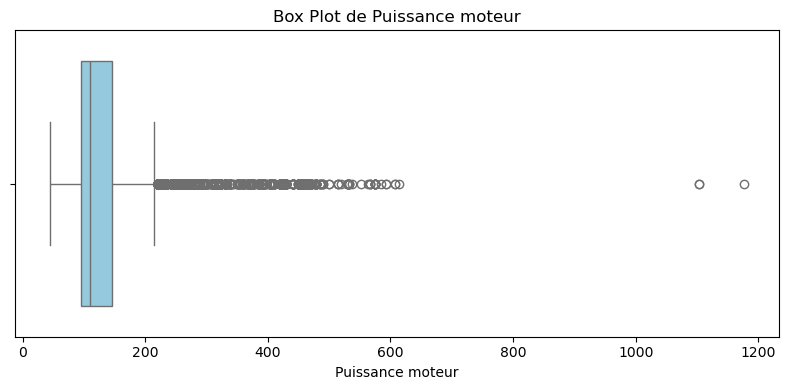

,Nb_Outliers,Pourcentage
Puissance moteur,2575,10.76


In [190]:
detecter_outliers(df['Puissance moteur'])

In [191]:
df_outliers_Consommation = df[df['Puissance moteur'] > 15].sort_values(by='Puissance moteur', ascending=True)
df_outliers_Consommation.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
14521,LAMBORGHINI,AVENTADOR,1715.0,448,essence,6498.0,566.0,18.0,0.330029,0.087104,3.788921,31.444444
17722,ASTON MARTIN,DBS 770 ULTIMATE,2020.0,314,essence,5204.0,566.0,13.9,0.280198,0.108762,2.576238,40.719424
19122,ASTON MARTIN,DBS 770 ULTIMATE VOLANTE,2020.0,314,essence,5204.0,566.0,13.9,0.280198,0.108762,2.576238,40.719424
14522,LAMBORGHINI,AVENTADOR,1740.0,442,essence,6498.0,574.0,18.0,0.329885,0.088335,3.734483,31.888889
14508,FERRARI,SF90 STRADALE,1820.0,160,hybride,3990.0,574.0,6.0,0.315385,0.143860,2.192308,95.666667
14527,LAMBORGHINI,AVENTADOR,1790.0,442,essence,6498.0,574.0,18.0,0.320670,0.088335,3.630168,31.888889
14509,FERRARI,SF90 STRADALE,1850.0,154,hybride,3990.0,574.0,6.1,0.310270,0.143860,2.156757,94.098361
14517,LAMBORGHINI,AVENTADOR,1780.0,440,essence,6498.0,574.0,19.5,0.322472,0.088335,3.650562,29.435897
14510,FERRARI,SF90 SPIDER,1925.0,149,hybride,3990.0,574.0,6.1,0.298182,0.143860,2.072727,94.098361
14516,LAMBORGHINI,AVENTADOR (COUNTACH),1780.0,440,essence,6498.0,574.0,19.5,0.322472,0.088335,3.650562,29.435897


## Consommation carburant

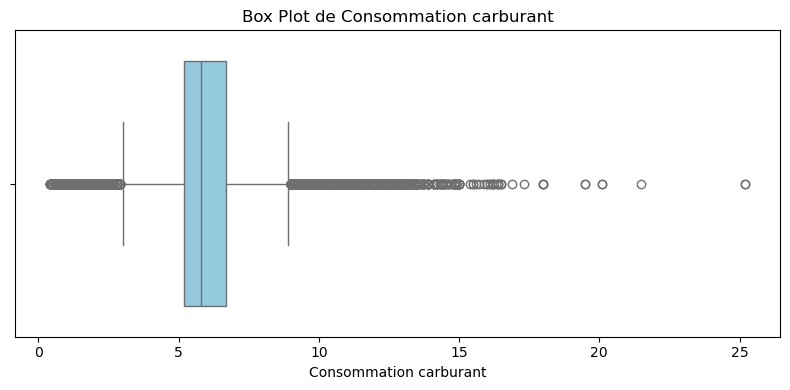

,Nb_Outliers,Pourcentage
Consommation carburant,3410,14.25


In [192]:
detecter_outliers(df['Consommation carburant'])

In [193]:
df_outliers_Consommation = df[df['Consommation carburant'] > 15].sort_values(by='Consommation carburant', ascending=True)
df_outliers_Consommation.tail(20)

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
18575,FERRARI,FERRARI DAYTONA SP3,1705.0,368,essence,6496.0,614.0,16.2,0.360117,0.094520,3.809971,37.901235
19565,FERRARI,812 COMPETIZIONE A,1810.0,370,essence,6496.0,607.0,16.3,0.335359,0.093442,3.588950,37.239264
2946,ROLLS-ROYCE,Cullinan Black Badge,2785.0,374,essence,6749.0,441.0,16.4,0.158348,0.065343,2.423339,26.890244
14512,FERRARI,812 GTS,1865.0,373,essence,6496.0,585.0,16.4,0.313673,0.090055,3.483110,35.670732
11576,MERCEDES BENZ,AMG G 63,2560.0,373,essence,3982.0,430.0,16.4,0.167969,0.107986,1.555469,26.219512
16543,CHEVROLET,CORVETTE,1833.0,377,essence,5460.0,475.0,16.5,0.259138,0.086996,2.978723,28.787879
22704,ROLLS-ROYCE,CULLINAN BLACK BADGE,2785.0,375,essence,6749.0,441.0,16.5,0.158348,0.065343,2.423339,26.727273
23418,CHEVROLET,CORVETTE,1789.0,377,essence,5460.0,475.0,16.5,0.265511,0.086996,3.051984,28.787879
14501,FERRARI,812 COMPETIZIONE,1740.0,385,essence,6496.0,607.0,16.9,0.348851,0.093442,3.733333,35.917160
17392,FERRARI,FERRARI PUROSANGUE,2245.0,393,essence,6496.0,529.0,17.3,0.235635,0.081435,2.893541,30.578035


# <font color='#3585CD'>Visualisation globale graphique</font>

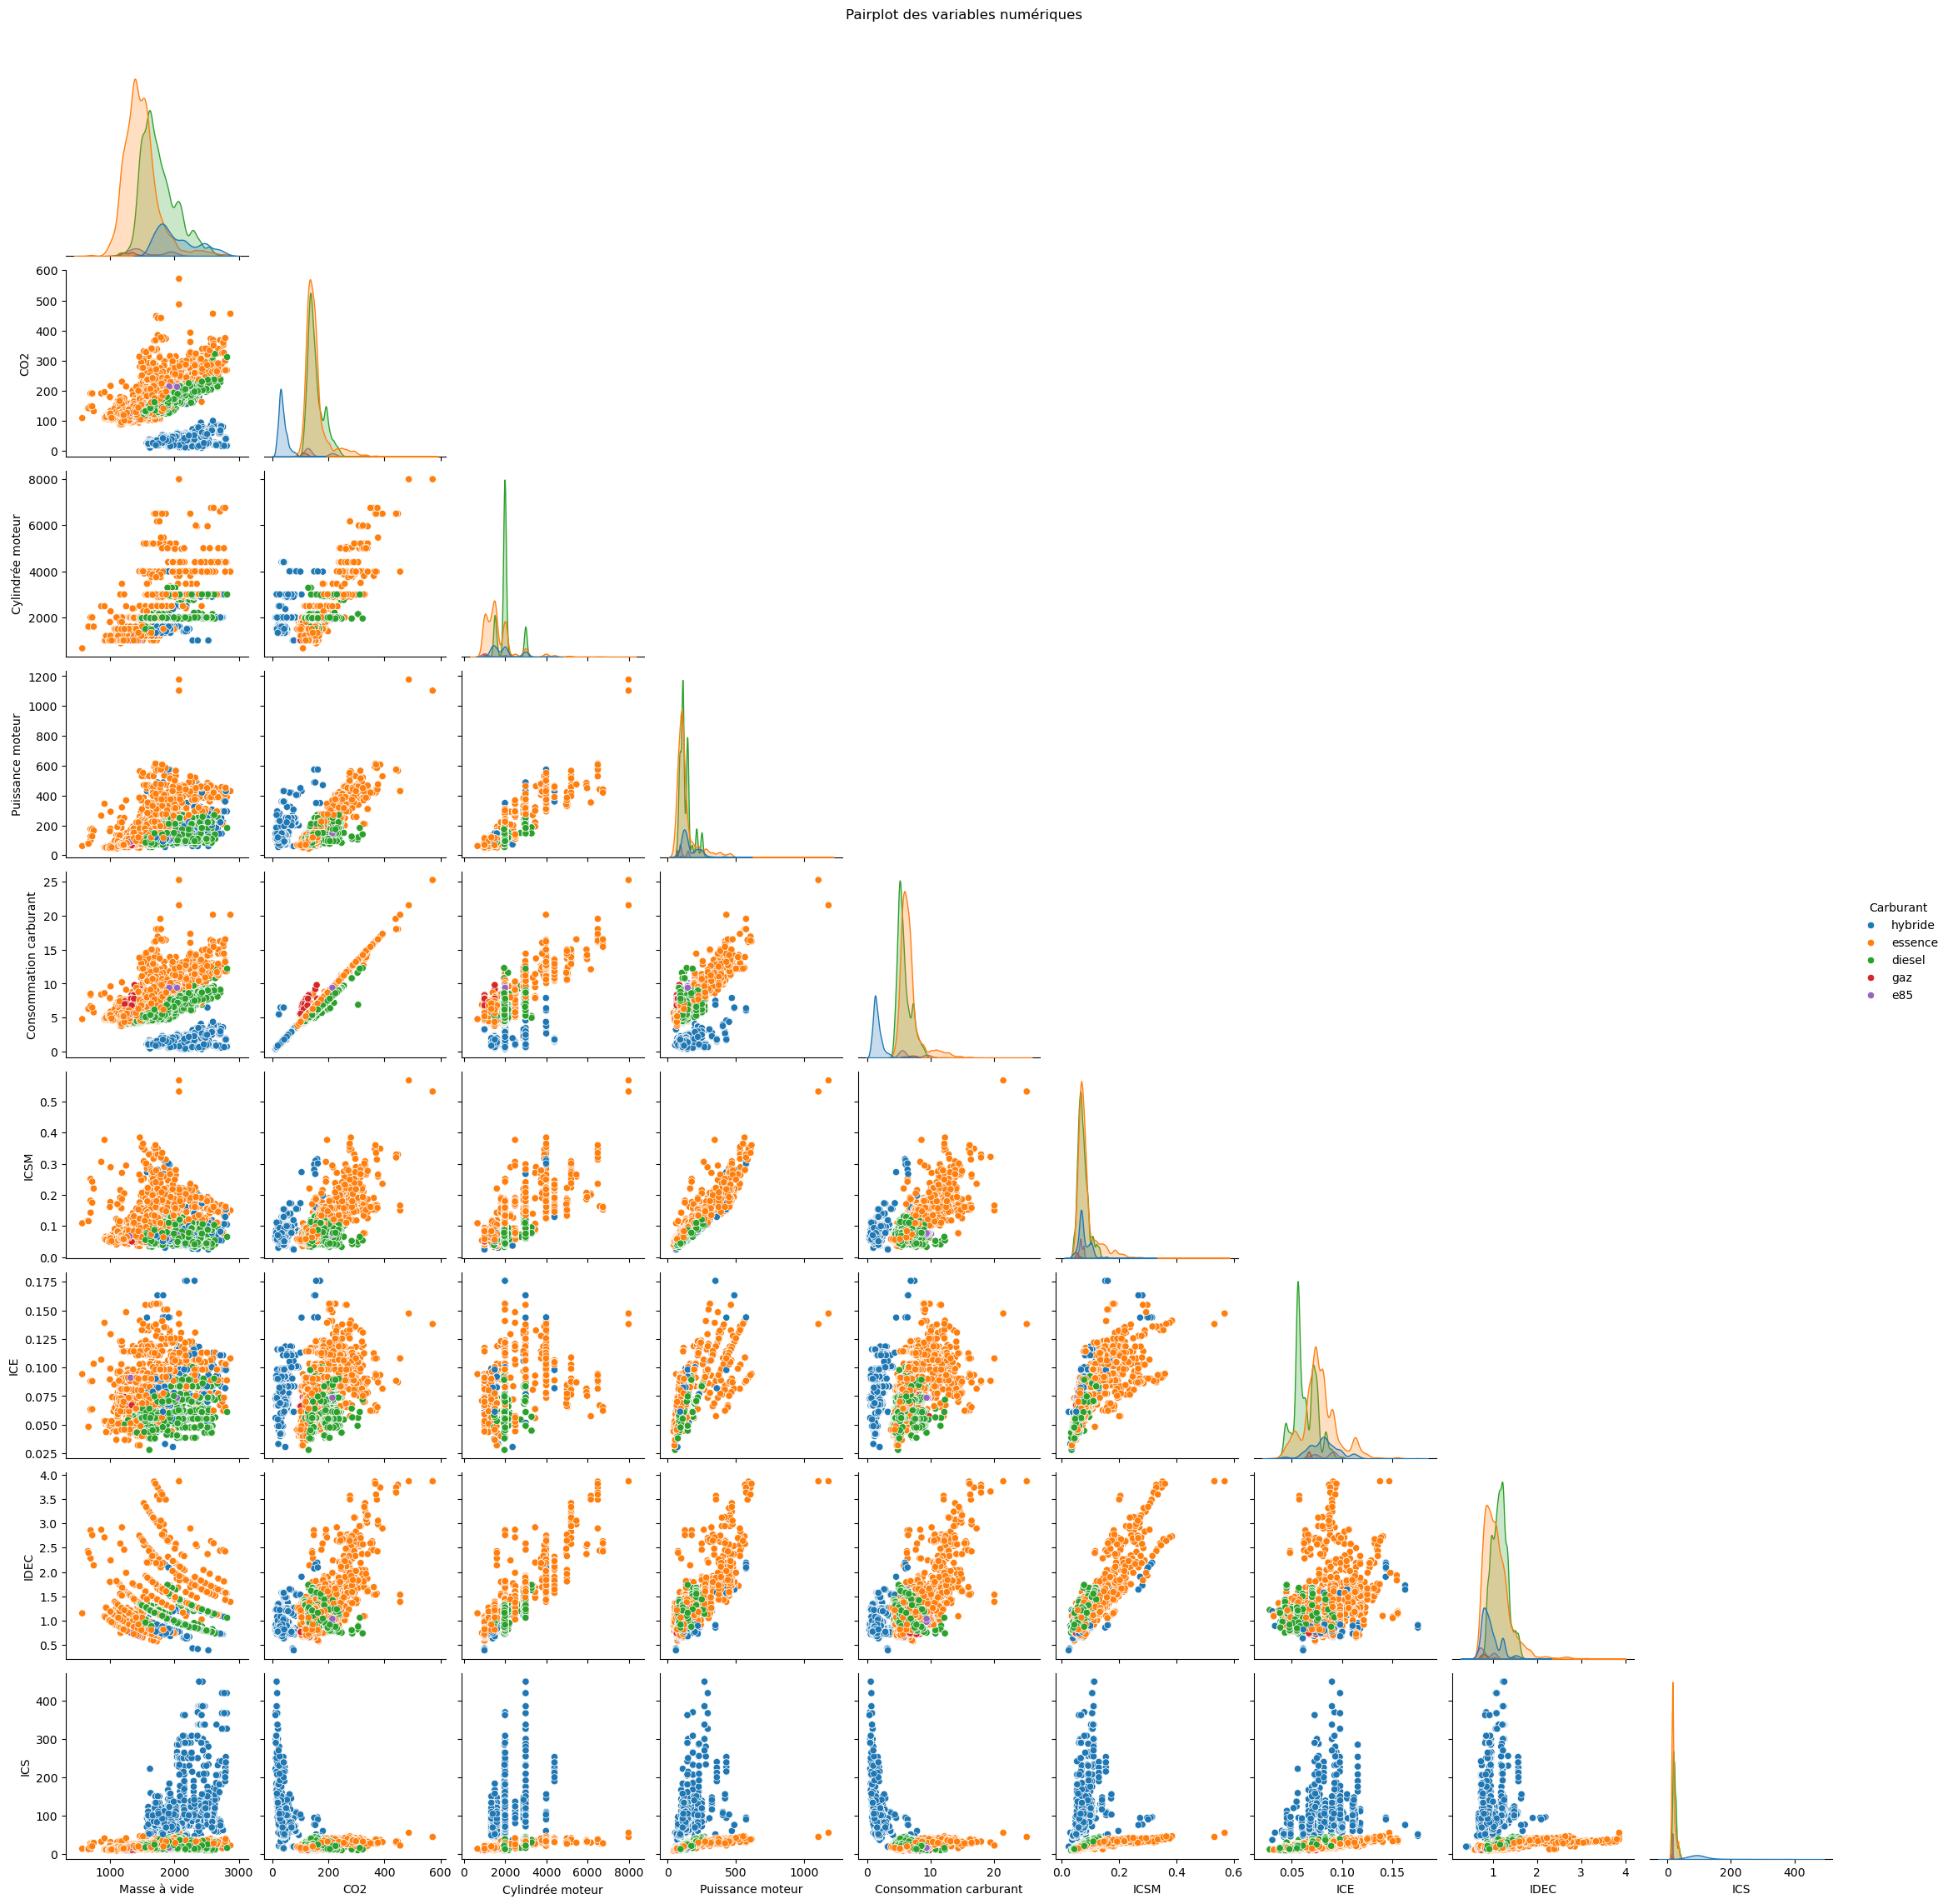

In [219]:
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
hue_var = 'Carburant'
if visualisation == 'plotly': 
    fig = px.scatter_matrix(df, dimensions=df.select_dtypes(include=['number']).columns,
                            color='Carburant', title="Pairplot des variables numériques")

    fig.update_layout(height=900, width=1200)
    fig.show()
elif visualisation == 'seaborn':
    # Pairplot Seaborn
    sns.pairplot(df[numeric_cols + [hue_var]], hue=hue_var, corner=True)
    plt.suptitle("Pairplot des variables numériques", y=1.02)
    plt.show()

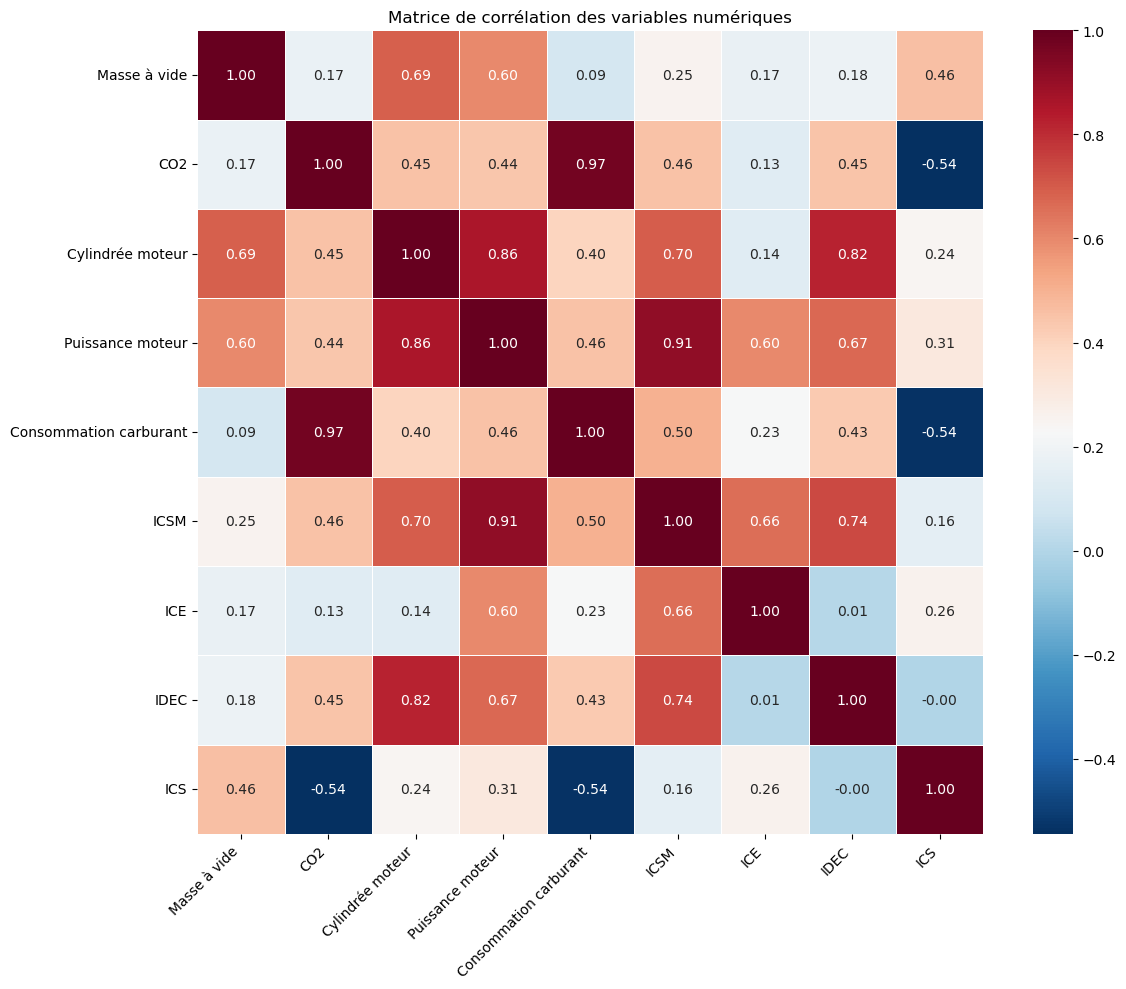

In [195]:
plot_correlation_matrix(df)

# <font color='#3585CD'>Distribution de la variable cible</font>





## Histogramme et boxplot de la variable cible

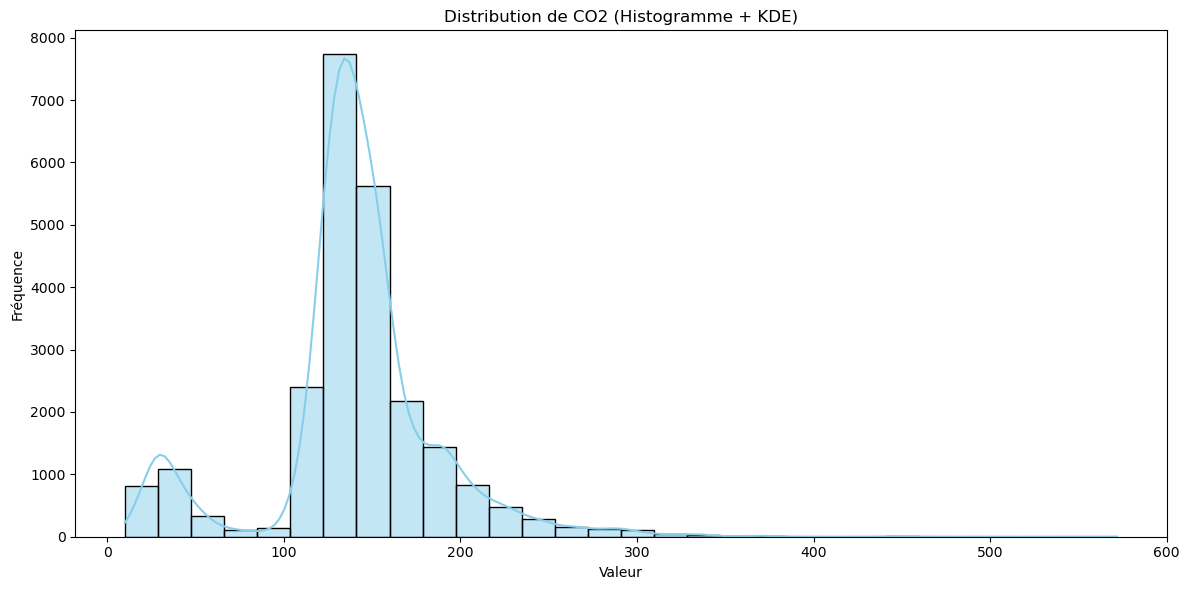

In [196]:
analyser_variables_numeriques(df, ['CO2'])

In [197]:
import plotly.graph_objects as go
import numpy as np
import scipy.stats as stats
import pandas as pd

# Calcul des quantiles
(quantiles, values), (slope, intercept, r) = stats.probplot(df['CO2'], dist="norm")

# Création du Q-Q Plot avec Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=quantiles, y=values, mode='markers', name='Données'))
fig.add_trace(go.Scatter(x=quantiles, y=slope * np.array(quantiles) + intercept, mode='lines', name='Ligne théorique'))

fig.update_layout(title='Q-Q plot pour CO2', xaxis_title='Quantiles théoriques', yaxis_title='Quantiles des données')

fig.show()

In [198]:
from statsmodels.stats.diagnostic import lilliefors
# Niveau de signification (alpha)
alpha = 0.05

# Effectuer les tests de normalité
shapiro_test = stats.shapiro(df['CO2'])
ks_test = stats.kstest(df['CO2'], 'norm')
ad_test = stats.anderson(df['CO2'], dist='norm')
dagostino_test = stats.normaltest(df['CO2'])
lilliefors_test = lilliefors(df['CO2'], dist='norm')

# Créer un tableau pandas avec les résultats des tests
test_results = pd.DataFrame({
    'Nom du test': ['Shapiro-Wilk', 'Kolmogorov-Smirnov', 'Anderson-Darling', "D'Agostino-Pearson", 'Lilliefors'],
    'Statistique de test': [shapiro_test[0], ks_test.statistic, ad_test.statistic, dagostino_test.statistic, lilliefors_test[0]],
    'p-valeur': [shapiro_test[1], ks_test.pvalue, None, dagostino_test.pvalue, lilliefors_test[1]],
    'Normalité': ['Oui' if shapiro_test[1] > alpha else 'Non',
                  'Oui' if ks_test.pvalue > alpha else 'Non',
                  'Oui' if any(ad_test.statistic < crit_val for crit_val in ad_test.critical_values) else 'Non',
                  'Oui' if dagostino_test.pvalue > alpha else 'Non',
                  'Oui' if lilliefors_test[1] > alpha else 'Non']
})

print(test_results)


          Nom du test  Statistique de test      p-valeur Normalité
0        Shapiro-Wilk             0.895421  1.114616e-81       Non
1  Kolmogorov-Smirnov             1.000000  0.000000e+00       Non
2    Anderson-Darling           960.532022           NaN       Non
3  D'Agostino-Pearson          1891.924362  0.000000e+00       Non
4          Lilliefors             0.171282  1.000000e-03       Non


In [199]:
# from scipy.stats import boxcox

# df['co2_transformed'], lambda_boxcox = boxcox(df['Ewltp (g/km)'] + 1)  # Ajouter 1 pour éviter 0
# df

In [200]:
df['Carburant'].unique()

array(['hybride', 'essence', 'diesel', 'gaz', 'e85'], dtype=object)

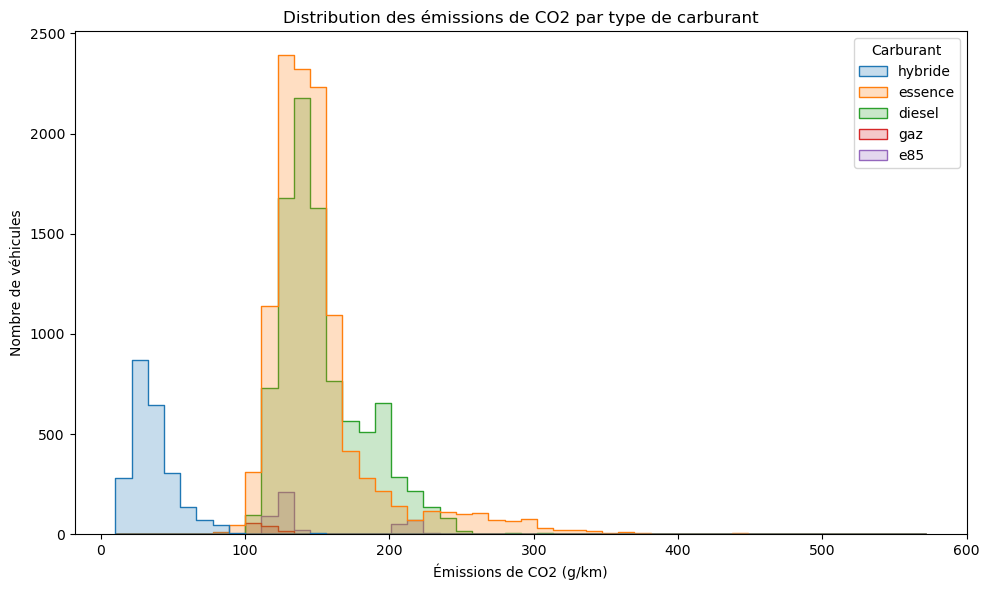

In [220]:
# Histogramme en fonction du type de motorisation
if visualisation == 'plotly':
    fig = px.histogram(df, x="CO2", color="Carburant", nbins=50, barmode="overlay",
                    title="Distribution des émissions de CO2 par type de carburant")
    fig.show()
elif visualisation == 'seaborn':
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x="CO2", hue="Carburant", bins=50, stat="count", element="step", common_norm=False)

    plt.title("Distribution des émissions de CO2 par type de carburant")
    plt.xlabel("Émissions de CO2 (g/km)")
    plt.ylabel("Nombre de véhicules")
    plt.tight_layout()
    plt.show()


Comment gérer ?


*   Création colonne Hybride ?
*   Dataset à part ?
*   Juste un OneHotEncoder ?

## Degrés d'asymétrie des variables

In [221]:
num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[num_vars].skew().sort_values()

CO2                       0.100928
Consommation carburant    0.385213
ICE                       0.796035
Masse à vide              0.822773
Cylindrée moteur          1.878756
IDEC                      2.209121
Puissance moteur          2.748144
ICSM                      3.261179
ICS                       5.360891
dtype: float64

### CO2

Légère asymétrie négative (peu inquiétante)

### Consommation carburant

 Quasi symétrique (très léger)

### Masse moyenne

Asymétrie positive modérée à forte, probablement due à des valeurs élevées qui tirent la distribution.

# <font color='#3585CD'>Quelles variables garder pour prédire le CO2 ?</font>

Selon nous, les **variables pertinentes** à garder pour la prédiction sont les suivantes :
* **Masse à vide** : un véhicule plus lourd a souvent des émissions plus élevées.
* **Cylindrée moteur** : une plus grande cylindrée est souvent associée à une plus grande consommation et donc plus d’émissions.
* **Puissance moteur** : un moteur plus puissant a tendance à consommer plus de carburant.
* **Carburant** : Essence, diesel, hybride… Chaque type influence les émissions. La variable Carburant sera encodée.

* **Consommation carburant** : directement liée aux émissions de CO2. Cependant sa forte corrélation peut expliquer à elle seule les émissions de CO2. Nous nous questionnerons au moment de la modélisation si nous la gardons ou pas.

Nous **excluerons** les variables **Marque** et **Modèle** qui ne sont pas directement liées aux émissions de CO2.

Pourquoi exclure les variables **Marque** et **Modèle** ?
* Ce sont des variables catégoriques à très haute **cardinalité**
* L'influence sur le CO₂ passe par des **caractéristiques techniques**

# <font color='#3585CD'>Export du dataset nettoyé</font>

In [203]:
df.shape

(23935, 12)

In [204]:
df = df.reset_index(drop=True)
df

,Marque,Modèle,Masse à vide,CO2,Carburant,Cylindrée moteur,Puissance moteur,Consommation carburant,ICSM,ICE,IDEC,ICS
0,JEEP,RENEGADE,1845.0,49,hybride,1332.0,96.0,2.0,0.052033,0.072072,0.721951,48.000000
1,JEEP,WRANGLER,1883.0,244,essence,1995.0,200.0,10.8,0.106213,0.100251,1.059480,18.518519
2,JEEP,WRANGLER,1972.0,259,essence,1995.0,200.0,11.5,0.101420,0.100251,1.011663,17.391304
3,JEEP,WRANGLER,1972.0,258,essence,1995.0,200.0,11.5,0.101420,0.100251,1.011663,17.391304
4,JEEP,WRANGLER UNLIMITED,2348.0,79,hybride,1995.0,200.0,3.5,0.085179,0.100251,0.849659,57.142857
...,...,...,...,...,...,...,...,...,...,...,...,...
23930,SKODA,SCALA,1211.0,119,essence,999.0,70.0,5.2,0.057803,0.070070,0.824938,13.461538
23931,FORD,TRANSIT CUSTOM,2311.0,197,diesel,1995.0,95.0,7.5,0.041108,0.047619,0.863263,12.666667
23932,MERCEDES BENZ,A 200,1440.0,144,essence,1332.0,120.0,6.3,0.083333,0.090090,0.925000,19.047619
23933,MERCEDES BENZ,V-KLASSE,2220.0,225,diesel,1950.0,174.0,8.6,0.078378,0.089231,0.878378,20.232558


In [205]:
# Vérifier si on est sur Google Colab
import os
try:
    import google.colab
    ON_COLAB = True
    dataset_path = "/content/drive/My Drive/Formation DS/Projet CO2/NOV24-CDS-CO2/notebooks/datasets/Dataset_final/datas_nettoyees_model_FR.csv"

    # Monter Google Drive si ce n'est pas déjà fait
    from google.colab import drive
    drive.mount('/content/drive')

except ImportError:
    ON_COLAB = False
    dataset_path = "datasets/Dataset_final/datas_nettoyees_model_FR.csv"

# Sauvegarde du DataFrame
df.to_csv(dataset_path, index=False)

# Vérification de l'enregistrement
if os.path.exists(dataset_path):
    print(f"Le fichier a bien été enregistré à l'emplacement : {dataset_path}")
else:
    print("Problème lors de l'enregistrement du fichier.")


Le fichier a bien été enregistré à l'emplacement : datasets/Dataset_final/datas_nettoyees_model_FR.csv


In [206]:
# dataset_path = "datasets/Dataset_final/datas_nettoyees_model_FR.csv"
# df.to_csv(dataset_path, index =False)

# import os

# # Vérifie si le fichier existe
# if os.path.exists(dataset_path):
#     print("Le fichier a bien été enregistré.")
# else:
#     print("Problème lors de l'enregistrement du fichier.")
